# Notebook 05 — Advanced Econometric Models

## 1. Purpose and Scope

This notebook extends the **baseline** models from
`notebooks/04_baseline_econometric_models.ipynb` (already implemented and
validated; **not modified here**). Notebook 04 established the core association
between individual characteristics and employment probability using a Linear
Probability Model (LPM), Logit, Probit, and a Logit with country fixed effects.

Notebook 05 does two things:

1. **Tests H2 and H5 directly** — H2 (whether country-level AI adoption
   moderates the education/digital-readiness-employment association) requires
   interaction terms, which notebook 04 deliberately did not include. H5
   (institutional/health/discrimination determinants, plus unobserved
   country heterogeneity) is stress-tested here with country-clustered
   standard errors and a country fixed-effects + interactions specification.
2. **Stress-tests H1, H3, H4** from notebook 04 with the advanced checks
   identified as missing in the quality review
   (`outputs/reports/notebook_02_03_04_quality_review.md`): a formal
   multicollinearity check (VIF), a survey-weighted comparison, and
   country-clustered standard errors.

**Boundaries (do not cross in this notebook)**
- Uses `data/pickle/final_employment_ai_dataset.pkl` exactly as saved by
  notebook 03 — **no data engineering, recoding, or new variables are created
  here**. Interaction terms used below were already built in notebook 03.
- Uses the **same core variable set (`BASE_VARS`) as notebook 04**, so results
  remain directly comparable in notebook 07 — not all 1,291 columns of the
  final dataset.
- **No exploratory data analysis** (see notebook 02) — only the minimal
  missingness/sample-size checks needed before modelling.
- **No machine learning models** (see notebook 06).
- **No PCA or other dimension reduction.**
- **No instrumental variables / 2SLS and no difference-in-differences** — the
  ESS data used here is cross-sectional, not a panel, and no valid instrument
  has been identified for AI adoption; these designs are out of scope for this
  thesis.
- Only **association language** is used throughout ("is associated with",
  "predicts", "correlates with", "is linked to") — **no causal claims**,
  consistent with `docs/methodology_notes.md`.

**Dependent variable**: `employed`

**Interaction terms tested** (all pre-built in notebook 03; skipped and
documented if missing): `education_years_x_ai_adoption`,
`digital_readiness_x_ai_adoption` (H2), `female_x_children` (H3),
`migration_x_education`, `migration_x_digital_readiness` (H4), and
`female_x_children_x_ai_adoption` (H3/H5) if available. No additional,
uninstructed interaction terms are added.

**Advanced checks added in this notebook** (per the quality review):
- Variance Inflation Factor (VIF) for the baseline and interaction variable
  sets (section 3).
- Interaction (Logit, LPM-fallback-if-needed) models (section 4).
- Marginal effects / predicted probabilities at low, median, and high AI
  adoption levels (section 5).
- Weighted (using `survey_weight`, built in notebook 03) vs. unweighted
  comparison (section 6).
- Country-clustered standard errors, with an explicit small-cluster caveat
  (section 7).
- Country fixed effects combined with interaction terms, with convergence
  checked and reported explicitly (section 8).
- Targeted robustness checks: with/without AI variable, with/without
  interactions, age 18-64 vs. full sample, with/without country fixed effects
  (section 9). No additional robustness checks are added beyond these.

**Estimator choice**: Logit is used by default, consistent with notebook 04's
main baseline estimator. If Logit fails to converge or shows signs of
(quasi-)perfect separation, the model falls back to a Linear Probability Model
(LPM, OLS/WLS with HC1-family robust standard errors), and this substitution is
always printed and logged — never hidden.

**Notebook structure**
1. Purpose and scope
2. Load final dataset and select modelling variables
3. VIF check
4. Interaction models
5. Marginal effects at representative AI adoption levels
6. Weighted vs. unweighted comparison
7. Country-clustered standard errors
8. Country fixed effects with interactions
9. Robustness checks
10. Model comparison table
11. Hypothesis interpretation
12. Save outputs

**Outputs saved**
- `outputs/tables/advanced_econometric_results.xlsx`
- `outputs/tables/vif_results.xlsx`
- `outputs/figures/advanced_econometric_coefficients.png`
- `outputs/figures/marginal_effects_ai_adoption.png`
- `outputs/reports/advanced_econometric_interpretation.md`

This notebook saves all results so it does not need to be rerun every time it is
read or cited from the thesis text.

## Environment Setup

Run the install cell below **once** if you get a `ModuleNotFoundError` (for
example, `No module named 'pandas'`) — skip it if packages are already installed.
Make sure the correct kernel/virtual environment is selected in VS Code before
running any other cell. Full setup instructions:
[docs/environment_setup.md](../docs/environment_setup.md).

In [1]:
# OPTIONAL: run only if a package is missing (e.g. ModuleNotFoundError: No module named 'pandas').
# Safe to skip if all packages in requirements.txt are already installed in this kernel.
from pathlib import Path

_project_root_for_install = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
_requirements_path = _project_root_for_install / 'requirements.txt'

if not _requirements_path.exists():
    print(f'requirements.txt not found at {_requirements_path}. See docs/environment_setup.md.')
else:
    %pip install -r "{_requirements_path}"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports and path setup for this notebook (econometrics: pandas, numpy, matplotlib, statsmodels).
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from scipy import stats
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    import warnings
except ImportError as exc:
    raise ImportError(
        f"Missing package: {exc.name}. Run the optional install cell above (or "
        "`pip install -r requirements.txt` in a terminal), then restart the kernel and re-run this cell."
    ) from exc

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
PICKLE_DIR = DATA_DIR / 'pickle'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
TABLES_DIR = OUTPUTS_DIR / 'tables'
REPORTS_DIR = OUTPUTS_DIR / 'reports'
MODELS_DIR = OUTPUTS_DIR / 'models'
DOCS_DIR = PROJECT_ROOT / 'docs'
for d in [PROCESSED_DIR, PICKLE_DIR, FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('Project root:', PROJECT_ROOT)

Project root: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis


## 2. Load Final Dataset and Select Modelling Variables

Loads the exact dataset saved by notebook 03 — no re-cleaning, recoding, or
filtering happens here beyond selecting the columns needed for modelling. The
variable set (`BASE_VARS`) is **identical to notebook 04**, so results remain
directly comparable in notebook 07.

In [3]:
dataset_path = PICKLE_DIR / 'final_employment_ai_dataset.pkl'
if not dataset_path.exists():
    raise FileNotFoundError(
        f'{dataset_path} not found. Run notebooks/03_data_engineering_and_final_dataset.ipynb '
        'first to produce the final dataset. Do not proceed with simulated data.'
    )

df = pd.read_pickle(dataset_path)
print('Loaded final dataset:', dataset_path)
print('Shape:', df.shape)
df.head()

Loaded final dataset: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\data\pickle\final_employment_ai_dataset.pkl
Shape: (49837, 1291)


,employed,age,age_squared,female,education_years,education_level,high_education,married,children_household,household_size,...,reg11_soexgdp_2014,reg11_soexgdp_2015,reg11_soexgdp_2016,reg11_soexgdp_2017,reg11_soexgdp_2018,reg11_soexgdp_2019,reg11_soexgdp_2020,reg11_soexgdp_2021,reg11_soexgdp_2022,reg11_soexgdp_2023
0,0,65.0000,"4,225.0000",0,12.0000,3.0000,0,1,0,2.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,21.0000,441.0000,1,14.0000,5.0000,1,0,0,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,53.0000,"2,809.0000",1,16.0000,6.0000,1,1,0,3.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,78.0000,"6,084.0000",1,14.0000,5.0000,1,0,0,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,64.0000,"4,096.0000",0,12.0000,3.0000,0,1,0,2.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
DEPENDENT_VAR = 'employed'

# Identical to notebooks/04_baseline_econometric_models.ipynb, so results stay comparable in notebook 07.
BASE_VARS = [
    'education_years', 'digital_readiness', 'female', 'children_household',
    'migration_background', 'health_status', 'age', 'age_squared', 'married',
    'household_size', 'institutional_trust_index', 'discrimination_experience',
    'ai_adoption_enterprises_pct',
]

INTERACTION_VARS = [
    'education_years_x_ai_adoption',    # H2
    'digital_readiness_x_ai_adoption',  # H2
    'female_x_children',                # H3
    'migration_x_education',            # H4
    'migration_x_digital_readiness',    # H4
]

OPTIONAL_TRIPLE_INTERACTION = 'female_x_children_x_ai_adoption'  # H3 / H5, used only if available

COUNTRY_VAR = 'country'
WEIGHT_VAR = 'survey_weight'

if DEPENDENT_VAR not in df.columns:
    raise KeyError(f'Dependent variable "{DEPENDENT_VAR}" not found in the final dataset. Cannot continue.')

def check_variables(varlist, label):
    """Checks which variables in varlist exist in df and have at least some
    non-missing data. Returns (available, excluded_with_reason)."""
    available, excluded = [], []
    for var in varlist:
        if var not in df.columns:
            excluded.append({'variable': var, 'group': label, 'status': 'not found in final dataset'})
        elif df[var].notna().sum() == 0:
            excluded.append({'variable': var, 'group': label, 'status': 'column exists but 100% missing'})
        else:
            available.append(var)
    return available, excluded

available_base_vars, excluded_base = check_variables(BASE_VARS, 'base')
available_interaction_vars, excluded_interactions = check_variables(INTERACTION_VARS, 'interaction')
triple_available, excluded_triple = check_variables([OPTIONAL_TRIPLE_INTERACTION], 'optional_triple_interaction')
available_interaction_vars_with_triple = available_interaction_vars + triple_available

country_available = COUNTRY_VAR in df.columns and df[COUNTRY_VAR].notna().sum() > 0
weight_available = WEIGHT_VAR in df.columns and df[WEIGHT_VAR].notna().sum() > 0
age_available = 'age' in available_base_vars

variable_check_df = pd.DataFrame(
    [{'variable': v, 'group': 'base', 'status': 'available'} for v in available_base_vars]
    + [{'variable': v, 'group': 'interaction', 'status': 'available'} for v in available_interaction_vars_with_triple]
    + excluded_base + excluded_interactions + excluded_triple
)

print(f'{len(available_base_vars)} of {len(BASE_VARS)} base variables available (identical set to notebook 04).')
print(f'{len(available_interaction_vars)} of {len(INTERACTION_VARS)} required interaction variables available.')
print(f'Optional triple interaction ({OPTIONAL_TRIPLE_INTERACTION}) available: {bool(triple_available)}')
if excluded_base or excluded_interactions or excluded_triple:
    print('Excluded from modelling (documented, not invented):')
    for row in excluded_base + excluded_interactions + excluded_triple:
        print(f"  - {row['variable']} ({row['group']}): {row['status']}")
print('Country variable available for fixed-effects/clustering:', country_available)
print('Survey weight available for weighted check:', weight_available)
variable_check_df

13 of 13 base variables available (identical set to notebook 04).
5 of 5 required interaction variables available.
Optional triple interaction (female_x_children_x_ai_adoption) available: True
Country variable available for fixed-effects/clustering: True
Survey weight available for weighted check: True


,variable,group,status
0,education_years,base,available
1,digital_readiness,base,available
2,female,base,available
3,children_household,base,available
4,migration_background,base,available
5,health_status,base,available
6,age,base,available
7,age_squared,base,available
8,married,base,available
9,household_size,base,available


In [5]:
required_cols = [DEPENDENT_VAR] + available_base_vars + available_interaction_vars_with_triple + ([COUNTRY_VAR] if country_available else [])
optional_cols = [WEIGHT_VAR] if weight_available else []

n_before = len(df)
sample = df[required_cols + optional_cols].dropna(subset=required_cols).copy()
n_after = len(sample)
n_dropped = n_before - n_after

print(f'Modelling sample: {n_after} of {n_before} rows kept ({n_dropped} dropped due to missing values in: {required_cols}).')
if weight_available:
    n_missing_weight = sample[WEIGHT_VAR].isna().sum()
    print(f'Survey weight missing for {n_missing_weight} of {n_after} rows in this sample (only affects the weighted check in section 6).')

missingness_pct = (df[required_cols].isna().mean() * 100).round(2).rename('missing_pct_in_full_dataset')
sample_missingness_df = missingness_pct.reset_index().rename(columns={'index': 'variable'})
print('\nMissingness (%) of each modelling variable in the full final dataset (before listwise deletion):')
print(missingness_pct)
sample.head()

Modelling sample: 41265 of 49837 rows kept (8572 dropped due to missing values in: ['employed', 'education_years', 'digital_readiness', 'female', 'children_household', 'migration_background', 'health_status', 'age', 'age_squared', 'married', 'household_size', 'institutional_trust_index', 'discrimination_experience', 'ai_adoption_enterprises_pct', 'education_years_x_ai_adoption', 'digital_readiness_x_ai_adoption', 'female_x_children', 'migration_x_education', 'migration_x_digital_readiness', 'female_x_children_x_ai_adoption', 'country']).
Survey weight missing for 0 of 41265 rows in this sample (only affects the weighted check in section 6).

Missingness (%) of each modelling variable in the full final dataset (before listwise deletion):
employed                           0.0000
education_years                    1.6100
digital_readiness                  0.1000
female                             0.0000
children_household                 0.0000
migration_background               0.0000
h

,employed,education_years,digital_readiness,female,children_household,migration_background,health_status,age,age_squared,married,...,discrimination_experience,ai_adoption_enterprises_pct,education_years_x_ai_adoption,digital_readiness_x_ai_adoption,female_x_children,migration_x_education,migration_x_digital_readiness,female_x_children_x_ai_adoption,country,survey_weight
0,0,12.0000,5.0000,0,0,0,3.0000,65.0000,"4,225.0000",1,...,0,29.9500,359.4000,149.7500,0,0.0000,0.0000,0.0000,AT,0.1300
1,0,14.0000,5.0000,1,0,0,2.0000,21.0000,441.0000,0,...,0,29.9500,419.3000,149.7500,0,0.0000,0.0000,0.0000,AT,0.1076
2,1,16.0000,5.0000,1,0,0,1.0000,53.0000,"2,809.0000",1,...,1,29.9500,479.2000,149.7500,0,0.0000,0.0000,0.0000,AT,1.3237
3,0,14.0000,1.0000,1,0,1,3.0000,78.0000,"6,084.0000",0,...,0,29.9500,419.3000,29.9500,0,14.0000,1.0000,0.0000,AT,0.0583
4,0,12.0000,5.0000,0,0,0,2.0000,64.0000,"4,096.0000",1,...,0,29.9500,359.4000,149.7500,0,0.0000,0.0000,0.0000,AT,0.3511


## 3. VIF Check

Variance Inflation Factor (VIF) is computed for (a) the baseline variable set
(identical to notebook 04) and (b) the baseline set plus all available
interaction terms. Notebook 04 only screened pairwise correlations
(`|correlation| > 0.6`), which cannot detect multicollinearity arising from
combinations of three or more variables — this is a direct response to that
gap identified in the quality review.

**No variable is dropped in this notebook solely because of its VIF value.**
Interaction terms are mechanically correlated with their own component main
effects (e.g. `education_years_x_ai_adoption` with `education_years` and
`ai_adoption_enterprises_pct`), so elevated VIF for interaction terms is
expected and is not, on its own, a reason to drop a theory-driven term.

In [6]:
def compute_vif(varlist, data, label):
    """Computes VIF for each variable in varlist (plus an intercept), returning
    a tidy table sorted by VIF descending."""
    X = sm.add_constant(data[varlist].astype(float))
    vif_rows = []
    for i, col in enumerate(X.columns):
        if col == 'const':
            continue
        vif_value = variance_inflation_factor(X.values, i)
        vif_rows.append({'variable_set': label, 'variable': col, 'vif': round(vif_value, 3)})
    return pd.DataFrame(vif_rows).sort_values('vif', ascending=False).reset_index(drop=True)

vif_baseline = compute_vif(available_base_vars, sample, 'baseline (no interactions, same as notebook 04)')
print('VIF — baseline variable set (as used in notebook 04):')
vif_baseline

VIF — baseline variable set (as used in notebook 04):


,variable_set,variable,vif
0,"baseline (no interactions, same as notebook 04)",age_squared,36.8510
1,"baseline (no interactions, same as notebook 04)",age,36.2860
2,"baseline (no interactions, same as notebook 04)",household_size,1.9160
3,"baseline (no interactions, same as notebook 04)",digital_readiness,1.7120
4,"baseline (no interactions, same as notebook 04)",children_household,1.6390
5,"baseline (no interactions, same as notebook 04)",married,1.3990
6,"baseline (no interactions, same as notebook 04)",health_status,1.3020
7,"baseline (no interactions, same as notebook 04)",education_years,1.2560
8,"baseline (no interactions, same as notebook 04)",ai_adoption_enterprises_pct,1.2210
9,"baseline (no interactions, same as notebook 04)",institutional_trust_index,1.1740


In [7]:
vif_interaction_vars = available_base_vars + available_interaction_vars_with_triple
vif_interactions = compute_vif(vif_interaction_vars, sample, 'baseline + interaction terms')
print('VIF — baseline variables plus all available interaction terms:')
vif_interactions

VIF — baseline variables plus all available interaction terms:


,variable_set,variable,vif
0,baseline + interaction terms,age_squared,37.1280
1,baseline + interaction terms,age,36.5390
2,baseline + interaction terms,digital_readiness_x_ai_adoption,23.7460
3,baseline + interaction terms,education_years_x_ai_adoption,23.5510
4,baseline + interaction terms,ai_adoption_enterprises_pct,19.2240
5,baseline + interaction terms,migration_background,18.9590
6,baseline + interaction terms,migration_x_digital_readiness,15.9010
7,baseline + interaction terms,migration_x_education,12.6100
8,baseline + interaction terms,female_x_children,7.3820
9,baseline + interaction terms,digital_readiness,7.1780


In [8]:
vif_results = pd.concat([vif_baseline, vif_interactions], ignore_index=True)

VIF_MODERATE_THRESHOLD = 5
VIF_HIGH_THRESHOLD = 10

flagged_moderate = vif_results.loc[(vif_results['vif'] >= VIF_MODERATE_THRESHOLD) & (vif_results['vif'] < VIF_HIGH_THRESHOLD)]
flagged_high = vif_results.loc[vif_results['vif'] >= VIF_HIGH_THRESHOLD]

print(f'Variables with VIF >= {VIF_HIGH_THRESHOLD} (high multicollinearity):')
if flagged_high.empty:
    print('  none')
else:
    for _, row in flagged_high.iterrows():
        print(f"  - {row['variable']} ({row['variable_set']}): VIF = {row['vif']}")

print(f'\nVariables with {VIF_MODERATE_THRESHOLD} <= VIF < {VIF_HIGH_THRESHOLD} (moderate, interpret with care):')
if flagged_moderate.empty:
    print('  none')
else:
    for _, row in flagged_moderate.iterrows():
        print(f"  - {row['variable']} ({row['variable_set']}): VIF = {row['vif']}")

print(
    '\nInterpretation: VIF >= 10 indicates a variable\'s coefficient is estimated with substantially '
    'inflated variance due to near-linear dependence on the other regressors -- coefficients (especially '
    'signs) for these variables should be treated with caution. VIF between 5 and 10 is a moderate warning '
    'only. Interaction terms are mechanically correlated with their own component main effects, so elevated '
    'VIF for interaction terms is expected and, on its own, is NOT a reason to drop them -- dropping a '
    'theory-driven interaction term to reduce VIF would remove the exact effect (H2/H3/H4) this notebook is '
    'designed to test. No variable is dropped in this notebook solely because of its VIF value; any '
    'exclusion is driven only by data availability (section 2) and is documented there.'
)
vif_results

Variables with VIF >= 10 (high multicollinearity):
  - age_squared (baseline (no interactions, same as notebook 04)): VIF = 36.851
  - age (baseline (no interactions, same as notebook 04)): VIF = 36.286
  - age_squared (baseline + interaction terms): VIF = 37.128
  - age (baseline + interaction terms): VIF = 36.539
  - digital_readiness_x_ai_adoption (baseline + interaction terms): VIF = 23.746
  - education_years_x_ai_adoption (baseline + interaction terms): VIF = 23.551
  - ai_adoption_enterprises_pct (baseline + interaction terms): VIF = 19.224
  - migration_background (baseline + interaction terms): VIF = 18.959
  - migration_x_digital_readiness (baseline + interaction terms): VIF = 15.901
  - migration_x_education (baseline + interaction terms): VIF = 12.61

Variables with 5 <= VIF < 10 (moderate, interpret with care):
  - female_x_children (baseline + interaction terms): VIF = 7.382
  - digital_readiness (baseline + interaction terms): VIF = 7.178
  - education_years (baseline + 

,variable_set,variable,vif
0,"baseline (no interactions, same as notebook 04)",age_squared,36.8510
1,"baseline (no interactions, same as notebook 04)",age,36.2860
2,"baseline (no interactions, same as notebook 04)",household_size,1.9160
3,"baseline (no interactions, same as notebook 04)",digital_readiness,1.7120
4,"baseline (no interactions, same as notebook 04)",children_household,1.6390
5,"baseline (no interactions, same as notebook 04)",married,1.3990
6,"baseline (no interactions, same as notebook 04)",health_status,1.3020
7,"baseline (no interactions, same as notebook 04)",education_years,1.2560
8,"baseline (no interactions, same as notebook 04)",ai_adoption_enterprises_pct,1.2210
9,"baseline (no interactions, same as notebook 04)",institutional_trust_index,1.1740


## 4. Interaction Models

Estimates the pre-specified interaction model: all available base variables
plus all available interaction terms, in a single formula, alongside a
no-interaction base model (identical variable set to notebook 04) for direct
comparison. **Logit is tried first** (main baseline estimator, consistent with
notebook 04); if it fails to converge or shows signs of (quasi-)perfect
separation, the model automatically falls back to an LPM (OLS with HC1 robust
standard errors), and this is always printed and logged — never hidden.

In [9]:
def extract_results(res, model_name, include_odds_ratio=False):
    """Builds a tidy results table (coef, std err, test stat, p-value, 95% CI,
    significance stars, optionally odds ratios) from a fitted statsmodels result.
    Used consistently for every model in this notebook so results stay comparable."""
    conf = res.conf_int()
    conf.columns = ['ci_low', 'ci_high']
    table = pd.DataFrame({
        'coef': res.params,
        'std_err': res.bse,
        'stat': res.tvalues,
        'p_value': res.pvalues,
    }).join(conf)
    table['sig'] = table['p_value'].apply(lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else '')))
    if include_odds_ratio:
        table['odds_ratio'] = np.exp(table['coef'])
        table['odds_ratio_ci_low'] = np.exp(table['ci_low'])
        table['odds_ratio_ci_high'] = np.exp(table['ci_high'])
    table = table.reset_index().rename(columns={'index': 'variable'})
    table.insert(0, 'model', model_name)
    return table


def fit_binary_model(formula, data, model_name, weights_col=None, cov_type=None, cov_kwds=None):
    """Tries Logit by default. Falls back to LPM (OLS/WLS, HC1 robust SE unless
    cov_type/cov_kwds override it) if Logit fails to converge or shows signs of
    (quasi-)perfect separation. Convergence status and any fallback reason are
    ALWAYS printed -- never silently swallowed."""
    if weights_col is not None:
        res = smf.wls(formula, data=data, weights=data[weights_col]).fit(cov_type=cov_type or 'HC1', cov_kwds=cov_kwds)
        table = extract_results(res, model_name)
        return table, 'WLS (LPM, weighted)', res, (
            'Weighted models are estimated as LPM (WLS), not Logit, to keep the weighting mechanism '
            'transparent and directly comparable to the unweighted LPM partner check.'
        )

    try:
        logit_fit_kwargs = {'disp': 0, 'maxiter': 100, 'cov_type': cov_type or 'nonrobust'}
        if cov_kwds is not None:
            logit_fit_kwargs['cov_kwds'] = cov_kwds
        res = smf.logit(formula, data=data).fit(**logit_fit_kwargs)
        converged = res.mle_retvals.get('converged', True)
        max_abs_coef = res.params.drop('Intercept', errors='ignore').abs().max()
        if not converged:
            print(f'[{model_name}] WARNING: Logit reported converged=False (mle_retvals={res.mle_retvals}).')
        if max_abs_coef > 20:
            print(f'[{model_name}] WARNING: max |coefficient| = {max_abs_coef:.1f}, suggesting possible (quasi-)perfect separation.')
        if (not converged) or max_abs_coef > 20:
            raise RuntimeError(f'Logit unstable (converged={converged}, max |coef|={max_abs_coef:.1f}).')
        table = extract_results(res, model_name, include_odds_ratio=True)
        return table, 'Logit', res, ''
    except Exception as exc:
        note = f'Logit failed/unstable ({exc}); used LPM (OLS, HC1 robust SE) instead. This is reported, not hidden.'
        print(f'[{model_name}] {note}')
        res = smf.ols(formula, data=data).fit(cov_type=cov_type or 'HC1', cov_kwds=cov_kwds)
        table = extract_results(res, f'{model_name} (LPM fallback)')
        return table, 'LPM (fallback, robust SE)', res, note


INTERACTION_HYPOTHESIS_MAP = {
    'education_years_x_ai_adoption': 'H2',
    'digital_readiness_x_ai_adoption': 'H2',
    'female_x_children': 'H3',
    'migration_x_education': 'H4',
    'migration_x_digital_readiness': 'H4',
    'female_x_children_x_ai_adoption': 'H3/H5',
}

base_formula = f"{DEPENDENT_VAR} ~ {' + '.join(available_base_vars)}"
interaction_formula = f"{DEPENDENT_VAR} ~ {' + '.join(available_base_vars + available_interaction_vars_with_triple)}"
print('Base (no-interaction) model formula:', base_formula)
print('Interaction model formula:', interaction_formula)

Base (no-interaction) model formula: employed ~ education_years + digital_readiness + female + children_household + migration_background + health_status + age + age_squared + married + household_size + institutional_trust_index + discrimination_experience + ai_adoption_enterprises_pct
Interaction model formula: employed ~ education_years + digital_readiness + female + children_household + migration_background + health_status + age + age_squared + married + household_size + institutional_trust_index + discrimination_experience + ai_adoption_enterprises_pct + education_years_x_ai_adoption + digital_readiness_x_ai_adoption + female_x_children + migration_x_education + migration_x_digital_readiness + female_x_children_x_ai_adoption


In [10]:
base_table, base_model_type, base_res, base_note = fit_binary_model(base_formula, sample, 'Base model (no interactions)')
print(f'Base model estimated as: {base_model_type}')
if base_note:
    print('Note:', base_note)

interaction_table, interaction_model_type, interaction_res, interaction_note = fit_binary_model(interaction_formula, sample, 'Interaction model')
print(f'\nInteraction model estimated as: {interaction_model_type}')
if interaction_note:
    print('Note:', interaction_note)
print(interaction_res.summary())
interaction_table

Base model estimated as: Logit



Interaction model estimated as: Logit
                           Logit Regression Results                           
Dep. Variable:               employed   No. Observations:                41265
Model:                          Logit   Df Residuals:                    41245
Method:                           MLE   Df Model:                           19
Date:                Tue, 01 Sep 2026   Pseudo R-squ.:                  0.4201
Time:                        17:15:04   Log-Likelihood:                -16572.
converged:                       True   LL-Null:                       -28579.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -9.5268      0.222    -42.920      0.000      -9.962      -9.092
education_years              

,model,variable,coef,std_err,stat,p_value,ci_low,ci_high,sig,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,Interaction model,Intercept,-9.5268,0.2220,-42.9199,0.0000,-9.9618,-9.0917,***,0.0001,0.0000,0.0001
1,Interaction model,education_years,0.1186,0.0097,12.2471,0.0000,0.0996,0.1376,***,1.1260,1.1048,1.1475
2,Interaction model,digital_readiness,0.0326,0.0320,1.0206,0.3075,-0.0300,0.0953,,1.0332,0.9704,1.1000
3,Interaction model,female,-0.4413,0.0314,-14.0592,0.0000,-0.5028,-0.3798,***,0.6432,0.6048,0.6840
4,Interaction model,children_household,0.3714,0.0631,5.8853,0.0000,0.2477,0.4951,***,1.4498,1.2811,1.6407
5,Interaction model,migration_background,0.5283,0.2575,2.0519,0.0402,0.0237,1.0330,**,1.6961,1.0240,2.8095
6,Interaction model,health_status,-0.3752,0.0173,-21.6548,0.0000,-0.4091,-0.3412,***,0.6872,0.6642,0.7109
7,Interaction model,age,0.5147,0.0062,82.4375,0.0000,0.5024,0.5269,***,1.6731,1.6527,1.6937
8,Interaction model,age_squared,-0.0059,0.0001,-86.1713,0.0000,-0.0060,-0.0058,***,0.9941,0.9940,0.9942
9,Interaction model,married,0.0277,0.0328,0.8452,0.3980,-0.0366,0.0921,,1.0281,0.9641,1.0965


In [11]:
sig_interactions = interaction_table.loc[
    interaction_table['variable'].isin(available_interaction_vars_with_triple) & (interaction_table['p_value'] < 0.05)
]
print('Statistically significant interaction terms (p < 0.05):')
if sig_interactions.empty:
    print('  none')
else:
    for _, row in sig_interactions.iterrows():
        direction = 'positive' if row['coef'] > 0 else 'negative'
        hyp = INTERACTION_HYPOTHESIS_MAP.get(row['variable'], '?')
        print(f"  - {row['variable']} ({hyp}): {direction} association, coef = {row['coef']:.4f}, p = {row['p_value']:.3f}")

print(
    '\nNote: interaction coefficients on their own are not directly interpretable as marginal effects '
    '(see section 5) -- sign/significance here is only a first screen.'
)

Statistically significant interaction terms (p < 0.05):
  - education_years_x_ai_adoption (H2): negative association, coef = -0.0019, p = 0.000
  - digital_readiness_x_ai_adoption (H2): positive association, coef = 0.0087, p = 0.000
  - female_x_children (H3): negative association, coef = -0.9692, p = 0.000
  - migration_x_education (H4): negative association, coef = -0.0419, p = 0.001

Note: interaction coefficients on their own are not directly interpretable as marginal effects (see section 5) -- sign/significance here is only a first screen.


## 5. Marginal Effects at Representative AI Adoption Levels

Interaction coefficients alone should not be interpreted directly: in a
nonlinear model (Logit) the effect of one variable depends on the level of the
variable it interacts with, and even in a linear model (LPM) the total effect
of, e.g., `education_years` is `coef_education_years + coef_interaction *
ai_adoption_enterprises_pct`, which varies by country. This section reports
average marginal effects for the interaction model overall, plus predicted
probabilities at representative (10th/50th/90th percentile = low/median/high)
levels of `ai_adoption_enterprises_pct`, holding all other variables at their
modelling-sample mean.

In [12]:
if interaction_model_type == 'Logit':
    interaction_margeff = interaction_res.get_margeff(at='overall', method='dydx')
    ame_table = interaction_margeff.summary_frame().reset_index().rename(columns={'index': 'variable'})
    ame_table.insert(0, 'model', 'Interaction model (AME)')
    print('Average marginal effects (probability scale) for the interaction model:')
else:
    ame_table = interaction_table[['model', 'variable', 'coef', 'std_err', 'p_value']].copy()
    ame_table['model'] = 'Interaction model (LPM coefficients = marginal effects)'
    print('Interaction model was estimated as LPM -- coefficients are already marginal effects on the probability scale:')
ame_table

Average marginal effects (probability scale) for the interaction model:


,model,variable,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
0,Interaction model (AME),education_years,0.0153,0.0012,12.3224,0.0000,0.0129,0.0177
1,Interaction model (AME),digital_readiness,0.0042,0.0041,1.0206,0.3074,-0.0039,0.0123
2,Interaction model (AME),female,-0.0569,0.0040,-14.1746,0.0000,-0.0648,-0.0490
3,Interaction model (AME),children_household,0.0479,0.0081,5.8891,0.0000,0.0319,0.0638
4,Interaction model (AME),migration_background,0.0681,0.0332,2.0522,0.0402,0.0031,0.1332
5,Interaction model (AME),health_status,-0.0484,0.0022,-22.0850,0.0000,-0.0527,-0.0441
6,Interaction model (AME),age,0.0663,0.0005,130.4557,0.0000,0.0653,0.0673
7,Interaction model (AME),age_squared,-0.0008,0.0000,-146.5541,0.0000,-0.0008,-0.0008
8,Interaction model (AME),married,0.0036,0.0042,0.8453,0.3980,-0.0047,0.0119
9,Interaction model (AME),household_size,-0.0131,0.0018,-7.4502,0.0000,-0.0165,-0.0096


In [13]:
AI_VAR = 'ai_adoption_enterprises_pct'
ai_levels = {}
if AI_VAR in available_base_vars:
    ai_levels = {
        'low (p10)': sample[AI_VAR].quantile(0.10),
        'median (p50)': sample[AI_VAR].quantile(0.50),
        'high (p90)': sample[AI_VAR].quantile(0.90),
    }
print('Representative AI adoption levels used:', {k: round(v, 2) for k, v in ai_levels.items()})

base_means = sample[available_base_vars + available_interaction_vars_with_triple].mean()

def predicted_prob_at_ai_levels(res, model_type, moderator_var, interaction_col, ai_levels, base_means):
    """Predicted probability of employment at low/median/high AI adoption, for the
    moderator variable (education_years or digital_readiness) held at its sample
    10th/50th/90th percentile, holding all other variables at their sample mean."""
    rows = []
    for mod_label, mod_pct in [('low (p10)', 0.10), ('median (p50)', 0.50), ('high (p90)', 0.90)]:
        mod_value = sample[moderator_var].quantile(mod_pct)
        for ai_label, ai_value in ai_levels.items():
            row = base_means.copy()
            row[moderator_var] = mod_value
            row[AI_VAR] = ai_value
            if interaction_col in row.index:
                row[interaction_col] = mod_value * ai_value
            pred = res.predict(pd.DataFrame([row])).iloc[0]
            if model_type != 'Logit':
                pred = float(np.clip(pred, 0, 1))  # LPM predictions can fall outside [0, 1]; clipped for readability only
            rows.append({
                'moderator_variable': moderator_var, f'{moderator_var}_level': mod_label,
                f'{moderator_var}_value': round(mod_value, 2),
                'ai_adoption_level': ai_label, 'ai_adoption_value': round(ai_value, 2),
                'predicted_prob_employed': round(float(pred), 4),
            })
    return pd.DataFrame(rows)

print(
    'Interaction coefficients alone should not be interpreted directly -- the tables below report '
    'predicted probabilities at representative AI adoption levels, holding all other variables at their '
    'modelling-sample mean, as the primary basis for interpreting H2.'
)

marginal_effects_tables = []
if ai_levels and 'education_years_x_ai_adoption' in available_interaction_vars_with_triple:
    marginal_effects_tables.append(predicted_prob_at_ai_levels(
        interaction_res, interaction_model_type, 'education_years', 'education_years_x_ai_adoption', ai_levels, base_means
    ))
if ai_levels and 'digital_readiness_x_ai_adoption' in available_interaction_vars_with_triple:
    marginal_effects_tables.append(predicted_prob_at_ai_levels(
        interaction_res, interaction_model_type, 'digital_readiness', 'digital_readiness_x_ai_adoption', ai_levels, base_means
    ))

if marginal_effects_tables:
    marginal_effects_ai_table = pd.concat(marginal_effects_tables, ignore_index=True)
    print('Predicted probability of employment at representative AI adoption levels (H2):')
else:
    marginal_effects_ai_table = pd.DataFrame()
    print('Skipped H2 predicted-probability grid: ai_adoption_enterprises_pct or its interaction terms are not available.')

marginal_effects_ai_table

Representative AI adoption levels used: {'low (p10)': np.float64(8.93), 'median (p50)': np.float64(18.16), 'high (p90)': np.float64(34.54)}
Interaction coefficients alone should not be interpreted directly -- the tables below report predicted probabilities at representative AI adoption levels, holding all other variables at their modelling-sample mean, as the primary basis for interpreting H2.


Predicted probability of employment at representative AI adoption levels (H2):


,moderator_variable,education_years_level,education_years_value,ai_adoption_level,ai_adoption_value,predicted_prob_employed,digital_readiness_level,digital_readiness_value
0,education_years,low (p10),8.0000,low (p10),8.9300,0.3611,NaN,NaN
1,education_years,low (p10),8.0000,median (p50),18.1600,0.2993,NaN,NaN
2,education_years,low (p10),8.0000,high (p90),34.5400,0.2062,NaN,NaN
3,education_years,median (p50),13.0000,low (p10),8.9300,0.4842,NaN,NaN
4,education_years,median (p50),13.0000,median (p50),18.1600,0.3937,NaN,NaN
5,education_years,median (p50),13.0000,high (p90),34.5400,0.2523,NaN,NaN
6,education_years,high (p90),18.0000,low (p10),8.9300,0.6093,NaN,NaN
7,education_years,high (p90),18.0000,median (p50),18.1600,0.4967,NaN,NaN
8,education_years,high (p90),18.0000,high (p90),34.5400,0.3047,NaN,NaN
9,digital_readiness,NaN,NaN,low (p10),8.9300,0.2545,low (p10),1.0000


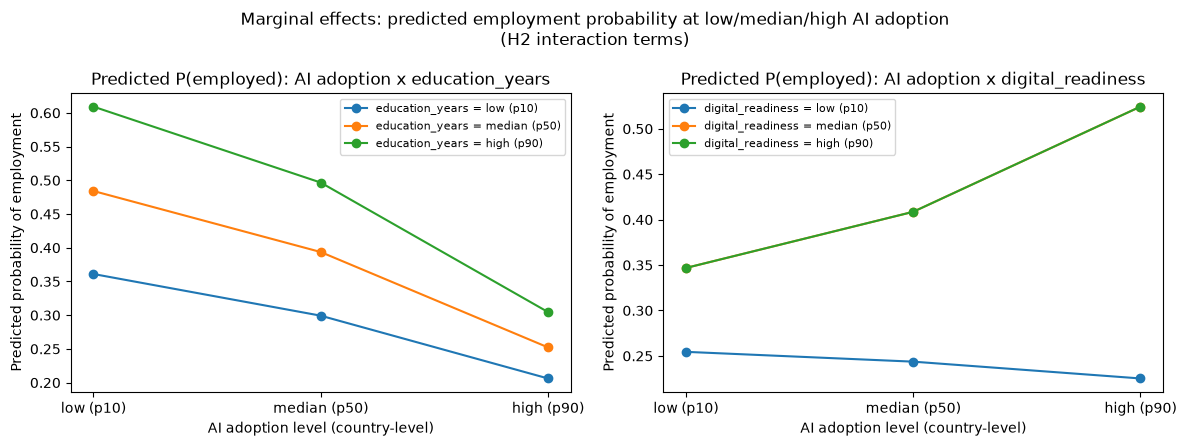

Saved marginal effects figure to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\figures\marginal_effects_ai_adoption.png


In [14]:
if not marginal_effects_ai_table.empty:
    moderators = list(marginal_effects_ai_table['moderator_variable'].unique())
    fig, axes = plt.subplots(1, len(moderators), figsize=(6 * len(moderators), 4.5), squeeze=False)
    level_order = ['low (p10)', 'median (p50)', 'high (p90)']
    for ax, mod_var in zip(axes[0], moderators):
        mod_df = marginal_effects_ai_table.loc[marginal_effects_ai_table['moderator_variable'] == mod_var]
        for mod_level in level_order:
            sub = mod_df.loc[mod_df[f'{mod_var}_level'] == mod_level].set_index('ai_adoption_level').reindex(level_order)
            ax.plot(level_order, sub['predicted_prob_employed'], marker='o', label=f'{mod_var} = {mod_level}')
        ax.set_xlabel('AI adoption level (country-level)')
        ax.set_ylabel('Predicted probability of employment')
        ax.set_title(f'Predicted P(employed): AI adoption x {mod_var}')
        ax.legend(fontsize=8)
    fig.suptitle('Marginal effects: predicted employment probability at low/median/high AI adoption\n(H2 interaction terms)')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'marginal_effects_ai_adoption.png', dpi=150)
    plt.show()
    print('Saved marginal effects figure to:', FIGURES_DIR / 'marginal_effects_ai_adoption.png')
else:
    print('Skipped marginal effects figure: no predicted-probability data available.')

## 6. Weighted vs. Unweighted Comparison

Uses `survey_weight` (built in notebook 03 from ESS `anweight`) to estimate a
weighted version of the interaction model and compares it with the unweighted
version on the **same sample and the same estimator** (LPM: WLS vs. OLS), so
that only the weighting — not the sample or the estimator — differs.

In [15]:
weighted_vs_unweighted_summary = 'Skipped: survey_weight not available.'
weighted_table = unweighted_table = weighted_vs_unweighted = pd.DataFrame()
weighted_model_type = None
weighted_res = unweighted_res = None

if weight_available:
    weight_sample = sample.dropna(subset=[WEIGHT_VAR]).copy()
    n_dropped_weight = len(sample) - len(weight_sample)
    print(f'Weighted/unweighted comparison sample: {len(weight_sample)} rows ({n_dropped_weight} dropped due to missing survey weight).')

    weighted_table, weighted_model_type, weighted_res, weighted_note = fit_binary_model(
        interaction_formula, weight_sample, 'Weighted (WLS)', weights_col=WEIGHT_VAR
    )
    unweighted_res = smf.ols(interaction_formula, data=weight_sample).fit(cov_type='HC1')
    unweighted_table = extract_results(unweighted_res, 'Unweighted (OLS)')

    comparison_cols = ['variable', 'coef', 'p_value']
    weighted_vs_unweighted = weighted_table[comparison_cols].merge(
        unweighted_table[comparison_cols], on='variable', suffixes=('_weighted', '_unweighted')
    )
    weighted_vs_unweighted['sign_agrees'] = np.sign(weighted_vs_unweighted['coef_weighted']) == np.sign(weighted_vs_unweighted['coef_unweighted'])
    weighted_vs_unweighted['significance_agrees_at_5pct'] = (
        (weighted_vs_unweighted['p_value_weighted'] < 0.05) == (weighted_vs_unweighted['p_value_unweighted'] < 0.05)
    )

    n_sign_disagree = int((~weighted_vs_unweighted['sign_agrees']).sum())
    n_sig_disagree = int((~weighted_vs_unweighted['significance_agrees_at_5pct']).sum())
    weighted_vs_unweighted_summary = (
        f'Compared on {len(weight_sample)} observations (both LPM, same sample -- WLS vs. OLS, so only the '
        f'weighting differs). {n_sign_disagree} of {len(weighted_vs_unweighted)} coefficients disagree in '
        f'sign, and {n_sig_disagree} disagree in significance at p < 0.05 between weighted and unweighted. '
        + ('Conclusions do not materially change under weighting.' if n_sign_disagree == 0 and n_sig_disagree == 0
           else 'Conclusions partially change under weighting -- see the flagged rows above.')
    )

print(weighted_vs_unweighted_summary)
weighted_vs_unweighted

Weighted/unweighted comparison sample: 41265 rows (0 dropped due to missing survey weight).


Compared on 41265 observations (both LPM, same sample -- WLS vs. OLS, so only the weighting differs). 1 of 20 coefficients disagree in sign, and 3 disagree in significance at p < 0.05 between weighted and unweighted. Conclusions partially change under weighting -- see the flagged rows above.


,variable,coef_weighted,p_value_weighted,coef_unweighted,p_value_unweighted,sign_agrees,significance_agrees_at_5pct
0,Intercept,-0.5874,0.0000,-0.4966,0.0000,True,True
1,education_years,0.0086,0.0001,0.0115,0.0000,True,True
2,digital_readiness,0.0283,0.0000,0.0202,0.0000,True,True
3,female,-0.0619,0.0000,-0.0490,0.0000,True,True
4,children_household,0.1268,0.0000,0.1300,0.0000,True,True
5,migration_background,0.0448,0.4171,0.0271,0.3687,True,True
6,health_status,-0.0417,0.0000,-0.0495,0.0000,True,True
7,age,0.0575,0.0000,0.0544,0.0000,True,True
8,age_squared,-0.0006,0.0000,-0.0006,0.0000,True,True
9,married,-0.0268,0.0019,-0.0116,0.0104,True,True


## 7. Country-Clustered Standard Errors

Estimates the interaction model with standard errors clustered by `country`
and compares them with non-clustered standard errors from the same
specification. **Small-cluster caveat**: with only ~30 countries, cluster-robust
standard error asymptotics are less reliable than with the conventionally
recommended 40-50+ clusters — these results are reported as indicative, not
definitive, alongside (not instead of) the non-clustered results.

In [16]:
country_clustered_summary = 'Skipped: country variable not available.'
se_comparison = pd.DataFrame()
clustered_table = pd.DataFrame()
clustered_model_type = None
clustered_res = None

if country_available:
    n_clusters = sample[COUNTRY_VAR].nunique()
    clustered_table, clustered_model_type, clustered_res, clustered_note = fit_binary_model(
        interaction_formula, sample, 'Interaction model (clustered SE)',
        cov_type='cluster', cov_kwds={'groups': sample[COUNTRY_VAR]},
    )
    nonclustered_table, nonclustered_model_type, nonclustered_res, nonclustered_note = fit_binary_model(
        interaction_formula, sample, 'Interaction model (non-clustered SE)'
    )
    print(f'Clustered SE model estimated as: {clustered_model_type}' + (f' ({clustered_note})' if clustered_note else ''))
    print(f'Non-clustered SE model estimated as: {nonclustered_model_type}' + (f' ({nonclustered_note})' if nonclustered_note else ''))

    se_comparison = nonclustered_table[['variable', 'coef', 'std_err', 'p_value']].merge(
        clustered_table[['variable', 'std_err', 'p_value']], on='variable', suffixes=('_nonclustered', '_clustered')
    )
    se_comparison['se_ratio_clustered_over_nonclustered'] = (
        se_comparison['std_err_clustered'] / se_comparison['std_err_nonclustered']
    ).round(3)

    country_clustered_summary = (
        f'Cluster-robust standard errors grouped by country ({n_clusters} clusters) estimated for the '
        f'interaction model ({clustered_model_type}). SMALL-CLUSTER CAVEAT: with only {n_clusters} clusters, '
        'cluster-robust standard error asymptotics are less reliable than with the conventionally recommended '
        '40-50+ clusters; these results should be read as indicative, not definitive, and are reported '
        'alongside -- not instead of -- the non-clustered results.'
    )

print(country_clustered_summary)
se_comparison

Clustered SE model estimated as: Logit
Non-clustered SE model estimated as: Logit
Cluster-robust standard errors grouped by country (25 clusters) estimated for the interaction model (Logit). SMALL-CLUSTER CAVEAT: with only 25 clusters, cluster-robust standard error asymptotics are less reliable than with the conventionally recommended 40-50+ clusters; these results should be read as indicative, not definitive, and are reported alongside -- not instead of -- the non-clustered results.


,variable,coef,std_err_nonclustered,p_value_nonclustered,std_err_clustered,p_value_clustered,se_ratio_clustered_over_nonclustered
0,Intercept,-9.5268,0.2220,0.0000,0.5427,0.0000,2.4450
1,education_years,0.1186,0.0097,0.0000,0.0242,0.0000,2.5010
2,digital_readiness,0.0326,0.0320,0.3075,0.0512,0.5241,1.6020
3,female,-0.4413,0.0314,0.0000,0.0847,0.0000,2.6990
4,children_household,0.3714,0.0631,0.0000,0.0936,0.0001,1.4830
5,migration_background,0.5283,0.2575,0.0402,0.2521,0.0361,0.9790
6,health_status,-0.3752,0.0173,0.0000,0.0334,0.0000,1.9290
7,age,0.5147,0.0062,0.0000,0.0185,0.0000,2.9600
8,age_squared,-0.0059,0.0001,0.0000,0.0002,0.0000,2.9950
9,married,0.0277,0.0328,0.3980,0.0606,0.6468,1.8450


## 8. Country Fixed Effects with Interactions

Attempts to estimate a model with country fixed effects and all available
interaction terms together. `ai_adoption_enterprises_pct` (a country-level
variable) is dropped from this specification only, since it is perfectly
collinear with country fixed effects; its interaction terms are kept, since
they vary *within* country by individual-level education/digital readiness.
Convergence is checked and reported explicitly — **not hidden inside a
try/except block**. If estimation is not feasible (e.g. too few countries with
outcome variation, or an estimation error), this is explained clearly and the
section is skipped.

In [17]:
country_fe_summary = 'Skipped: country variable not available.'
fe_interaction_res = None
fe_interaction_table = pd.DataFrame()
fe_vars = []
fe_sample = pd.DataFrame()

if not country_available:
    print(country_fe_summary)
else:
    fe_sample = sample.copy()
    outcome_variation = fe_sample.groupby(COUNTRY_VAR)[DEPENDENT_VAR].nunique()
    single_outcome_countries = outcome_variation[outcome_variation < 2].index.tolist()
    if single_outcome_countries:
        n_before_fe = len(fe_sample)
        fe_sample = fe_sample[~fe_sample[COUNTRY_VAR].isin(single_outcome_countries)].copy()
        print(f'Dropped {n_before_fe - len(fe_sample)} rows from {len(single_outcome_countries)} '
              f'countries with only one employment outcome (perfect-separation risk): {single_outcome_countries}')

    n_countries_fe = fe_sample[COUNTRY_VAR].nunique()
    # ai_adoption_enterprises_pct is a country-level variable and is perfectly collinear with country
    # fixed effects, so it is dropped from THIS specification only (documented, not silently omitted
    # elsewhere); its interaction terms are kept, since they vary within country.
    fe_base_vars = [v for v in available_base_vars if v != 'ai_adoption_enterprises_pct']
    fe_vars = fe_base_vars + available_interaction_vars_with_triple

    if n_countries_fe < 2:
        country_fe_summary = f'Not feasible: only {n_countries_fe} country(ies) with outcome variation remain after dropping single-outcome countries.'
        print(country_fe_summary)
    else:
        formula_fe_interactions = f"{DEPENDENT_VAR} ~ {' + '.join(fe_vars)} + C({COUNTRY_VAR})"
        print('Country FE + interactions formula:', formula_fe_interactions)
        try:
            fe_interaction_res = smf.logit(formula_fe_interactions, data=fe_sample).fit(disp=0, maxiter=200)
            fe_converged = fe_interaction_res.mle_retvals.get('converged', True)
            fe_iterations = fe_interaction_res.mle_retvals.get('iterations', None)
            print(f'Convergence status (reported explicitly, not hidden): converged={fe_converged}, iterations={fe_iterations}')
            if not fe_converged:
                print('WARNING: model did NOT converge cleanly. Coefficients below are reported for transparency '
                      'but should be treated with caution and are flagged as such in the model comparison table.')
            fe_interaction_table = extract_results(fe_interaction_res, 'Country FE + interactions', include_odds_ratio=True)
            country_fe_summary = (
                f'Estimated on {int(fe_interaction_res.nobs)} observations across {n_countries_fe} countries '
                f'(Logit + country fixed effects + all available interaction terms; ai_adoption_enterprises_pct '
                f'main effect dropped as collinear with country FE). Convergence: {fe_converged}.'
            )
        except Exception as exc:
            fe_interaction_res = None
            fe_interaction_table = pd.DataFrame()
            country_fe_summary = f'Not feasible: estimation raised an exception ({exc}). This is reported explicitly, not hidden.'
            print(country_fe_summary)

print('\nSummary:', country_fe_summary)
if fe_interaction_res is not None:
    print(fe_interaction_res.summary())

Country FE + interactions formula: employed ~ education_years + digital_readiness + female + children_household + migration_background + health_status + age + age_squared + married + household_size + institutional_trust_index + discrimination_experience + education_years_x_ai_adoption + digital_readiness_x_ai_adoption + female_x_children + migration_x_education + migration_x_digital_readiness + female_x_children_x_ai_adoption + C(country)


Convergence status (reported explicitly, not hidden): converged=True, iterations=8

Summary: Estimated on 41265 observations across 25 countries (Logit + country fixed effects + all available interaction terms; ai_adoption_enterprises_pct main effect dropped as collinear with country FE). Convergence: True.
                           Logit Regression Results                           
Dep. Variable:               employed   No. Observations:                41265
Model:                          Logit   Df Residuals:                    41222
Method:                           MLE   Df Model:                           42
Date:                Tue, 01 Sep 2026   Pseudo R-squ.:                  0.4294
Time:                        17:15:10   Log-Likelihood:                -16308.
converged:                       True   LL-Null:                       -28579.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err      

## 8a. Marginal Effects for the Country FE + Interactions Model
Average Marginal Effects (AME) for the interaction model with country fixed effects (section 8
above), computed the same way as the interaction model's AME earlier in this notebook
(`statsmodels .get_margeff(at='overall', method='dydx')`), so results are directly comparable.
Country dummy coefficients are excluded from the displayed/saved table.


In [18]:
fe_interaction_ame_table = pd.DataFrame()
fe_interaction_ame_note = None

if fe_interaction_res is not None:
    try:
        fe_interaction_margeff = fe_interaction_res.get_margeff(at='overall', method='dydx')
        fe_interaction_ame_table = fe_interaction_margeff.summary_frame().reset_index().rename(columns={'index': 'variable'})
        fe_interaction_ame_table.insert(0, 'model', 'Interaction + Country FE (AME)')
        fe_interaction_ame_table = fe_interaction_ame_table[
            ~fe_interaction_ame_table['variable'].astype(str).str.contains(r'C\(country\)', na=False)
        ].reset_index(drop=True)
        print('Interaction + Country FE: average marginal effects (probability scale) for non-country predictors:')
    except Exception as exc:
        fe_interaction_ame_note = f'AME could not be computed for the Interaction + Country FE model: {exc}'
        print(fe_interaction_ame_note)
else:
    fe_interaction_ame_note = 'Interaction + Country FE model was not estimated (see section 8 above); AME not applicable.'
    print(fe_interaction_ame_note)

fe_interaction_ame_table


Interaction + Country FE: average marginal effects (probability scale) for non-country predictors:


,model,variable,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
0,Interaction + Country FE (AME),education_years,0.0157,0.0013,12.3938,0.0000,0.0132,0.0182
1,Interaction + Country FE (AME),digital_readiness,0.0067,0.0041,1.6282,0.1035,-0.0014,0.0149
2,Interaction + Country FE (AME),female,-0.0596,0.0040,-14.9564,0.0000,-0.0674,-0.0518
3,Interaction + Country FE (AME),children_household,0.0383,0.0081,4.7456,0.0000,0.0225,0.0541
4,Interaction + Country FE (AME),migration_background,0.0729,0.0329,2.2196,0.0264,0.0085,0.1374
5,Interaction + Country FE (AME),health_status,-0.0534,0.0022,-23.8372,0.0000,-0.0578,-0.0490
6,Interaction + Country FE (AME),age,0.0668,0.0005,130.6605,0.0000,0.0658,0.0678
7,Interaction + Country FE (AME),age_squared,-0.0008,0.0000,-145.9827,0.0000,-0.0008,-0.0008
8,Interaction + Country FE (AME),married,0.0071,0.0042,1.6703,0.0949,-0.0012,0.0154
9,Interaction + Country FE (AME),household_size,-0.0103,0.0018,-5.8043,0.0000,-0.0138,-0.0068


## 8b. VIF Check on Fitted-Model Design Matrices (Logit + Country FE, Interaction Model, Interaction + Country FE)
The Section 3 VIF check above was computed on *variable sets* (all available base variables; base
variables plus interaction terms), not on the exact design matrix actually used to fit any specific
model. This section computes VIF directly on the design matrix (X) of three specific fitted models,
including any dummy/fixed-effect columns and interaction terms actually present in that matrix:
1. **Logit + Country FE** (no interaction terms) -- this model is fitted in Notebook 04 (Model 4),
   not in this notebook, so its design matrix is reconstructed here via `patsy.dmatrices` using the
   identical formula and identical country-filtering logic as Notebook 04's Model 4, applied to this
   notebook's own modelling sample. No model is re-estimated for this -- VIF depends only on X, not
   on fitted coefficients -- and no code in Notebook 04 is touched.
2. **Interaction model** (Section 4 above) -- uses `interaction_res.model.exog` directly, i.e. the
   exact matrix `statsmodels` used to fit that already-existing model object.
3. **Interaction + Country FE** (Section 8 above) -- uses `fe_interaction_res.model.exog` directly,
   the exact matrix used to fit that already-existing model object.

Each variable is flagged `"moderate"` (5 < VIF <= 10), `"high"` (VIF > 10), or `"ok"` otherwise.


In [19]:
import patsy

VIF_DIAG_MODERATE_THRESHOLD = 5
VIF_DIAG_HIGH_THRESHOLD = 10


def vif_diag_flag(v):
    if v > VIF_DIAG_HIGH_THRESHOLD:
        return 'high'
    elif v > VIF_DIAG_MODERATE_THRESHOLD:
        return 'moderate'
    else:
        return 'ok'


def compute_vif_from_exog(exog_values, exog_names, label, source_note):
    """Computes VIF for every non-intercept column of an ALREADY-BUILT design matrix (the exact
    matrix used to fit a specific model, or an identically-constructed one), flags moderate/high
    multicollinearity, and returns a tidy table. Does not fit or refit any model."""
    X = np.asarray(exog_values, dtype=float)
    rows = []
    for i, name in enumerate(exog_names):
        if name in ('Intercept', 'const'):
            continue
        vif_value = variance_inflation_factor(X, i)
        rows.append({
            'model': label,
            'variable': name,
            'vif': round(float(vif_value), 3),
            'flag': vif_diag_flag(vif_value),
            'source': source_note,
        })
    return pd.DataFrame(rows).sort_values('vif', ascending=False).reset_index(drop=True)


vif_diag_tables = []
vif_diag_missing_notes = []

# 1. Logit + Country FE (no interactions) -- fitted in Notebook 04 (Model 4), not here. Design matrix
# reconstructed via patsy using the identical formula/sample-filtering logic, on this notebook's sample.
logit_fe_vif_table = pd.DataFrame()
if not country_available:
    vif_diag_missing_notes.append('Logit + Country FE model VIF skipped: country variable not available.')
    print(vif_diag_missing_notes[-1])
else:
    logit_fe_vif_sample = sample.copy()
    outcome_variation_vif = logit_fe_vif_sample.groupby(COUNTRY_VAR)[DEPENDENT_VAR].nunique()
    single_outcome_countries_vif = outcome_variation_vif[outcome_variation_vif < 2].index.tolist()
    if single_outcome_countries_vif:
        logit_fe_vif_sample = logit_fe_vif_sample[~logit_fe_vif_sample[COUNTRY_VAR].isin(single_outcome_countries_vif)].copy()

    n_countries_vif = logit_fe_vif_sample[COUNTRY_VAR].nunique()
    logit_fe_vif_vars = [v for v in available_base_vars if v != 'ai_adoption_enterprises_pct']

    if n_countries_vif < 2:
        vif_diag_missing_notes.append(
            f'Logit + Country FE model VIF skipped: only {n_countries_vif} country(ies) with outcome '
            'variation remain after dropping single-outcome countries.'
        )
        print(vif_diag_missing_notes[-1])
    else:
        logit_fe_vif_formula = f"{DEPENDENT_VAR} ~ {' + '.join(logit_fe_vif_vars)} + C({COUNTRY_VAR})"
        _, X_logit_fe_vif = patsy.dmatrices(logit_fe_vif_formula, data=logit_fe_vif_sample, return_type='dataframe')
        logit_fe_vif_table = compute_vif_from_exog(
            X_logit_fe_vif.values, list(X_logit_fe_vif.columns), 'Logit + Country FE model',
            "patsy reconstruction of notebook 04 Model 4's formula, applied to this notebook's sample "
            "(design matrix only, not re-estimated; no coefficients from notebook 04 are reused)"
        )
        vif_diag_tables.append(logit_fe_vif_table)
        print(f'VIF computed for the Logit + Country FE design matrix ({n_countries_vif} countries, '
              f'{len(logit_fe_vif_sample)} observations, {X_logit_fe_vif.shape[1] - 1} non-intercept columns).')

# 2. Interaction model (Section 4) -- uses the exact fitted model object's own design matrix.
if interaction_model_type == 'Logit' and interaction_res is not None:
    interaction_vif_table = compute_vif_from_exog(
        interaction_res.model.exog, interaction_res.model.exog_names, 'Interaction model (no country FE)',
        'interaction_res.model.exog (exact matrix already used to fit this model, Section 4 above)'
    )
    vif_diag_tables.append(interaction_vif_table)
    print('VIF computed for the Interaction model design matrix (exact matrix used to fit interaction_res).')
else:
    interaction_vif_table = pd.DataFrame()
    vif_diag_missing_notes.append(
        f'Interaction model VIF skipped: model was estimated as "{interaction_model_type}", not Logit.'
    )
    print(vif_diag_missing_notes[-1])

# 3. Interaction + Country FE (Section 8) -- uses the exact fitted model object's own design matrix.
if fe_interaction_res is not None:
    fe_interaction_vif_table = compute_vif_from_exog(
        fe_interaction_res.model.exog, fe_interaction_res.model.exog_names, 'Interaction + Country FE model',
        'fe_interaction_res.model.exog (exact matrix already used to fit this model, Section 8 above)'
    )
    vif_diag_tables.append(fe_interaction_vif_table)
    print('VIF computed for the Interaction + Country FE design matrix (exact matrix used to fit fe_interaction_res).')
else:
    fe_interaction_vif_table = pd.DataFrame()
    vif_diag_missing_notes.append(
        'Interaction + Country FE model VIF skipped: this model was not estimated successfully in Section 8 above.'
    )
    print(vif_diag_missing_notes[-1])

vif_diagnostics_table = pd.concat(vif_diag_tables, ignore_index=True) if vif_diag_tables else pd.DataFrame()

print('\n--- VIF Diagnostics Summary (fitted-model design matrices) ---')
if vif_diagnostics_table.empty:
    print('No VIF diagnostics could be computed for any of the three target models.')
else:
    high_vif_rows = vif_diagnostics_table.loc[vif_diagnostics_table['flag'] == 'high']
    if high_vif_rows.empty:
        print('No variable in any of the three models has VIF > 10.')
    else:
        print('The following variables have VIF > 10 (high multicollinearity concern):')
        for _, row in high_vif_rows.iterrows():
            print(f"  - {row['variable']} ({row['model']}): VIF = {row['vif']}")
    moderate_vif_rows = vif_diagnostics_table.loc[vif_diagnostics_table['flag'] == 'moderate']
    print(f'\n{len(moderate_vif_rows)} variable(s) fall in the moderate range (5 < VIF <= 10) across all three models.')
    print(
        '\nNote: country fixed-effect dummy columns (C(country)[T.xxx]) are mechanically correlated with '
        'each other by construction (one-hot encoding of a categorical variable); elevated VIF among these '
        'dummy columns alone is expected and is not, on its own, evidence of a modelling problem -- the same '
        'reasoning already documented in Section 3 for interaction terms applies here.'
    )

if vif_diag_missing_notes:
    print('\nModels skipped (no values fabricated):')
    for _n in vif_diag_missing_notes:
        print(' -', _n)

vif_diagnostics_table


VIF computed for the Logit + Country FE design matrix (25 countries, 41265 observations, 36 non-intercept columns).


VIF computed for the Interaction model design matrix (exact matrix used to fit interaction_res).


VIF computed for the Interaction + Country FE design matrix (exact matrix used to fit fe_interaction_res).

--- VIF Diagnostics Summary (fitted-model design matrices) ---
The following variables have VIF > 10 (high multicollinearity concern):
  - age_squared (Logit + Country FE model): VIF = 37.276
  - age (Logit + Country FE model): VIF = 36.629
  - age_squared (Interaction model (no country FE)): VIF = 37.128
  - age (Interaction model (no country FE)): VIF = 36.539
  - digital_readiness_x_ai_adoption (Interaction model (no country FE)): VIF = 23.746
  - education_years_x_ai_adoption (Interaction model (no country FE)): VIF = 23.551
  - ai_adoption_enterprises_pct (Interaction model (no country FE)): VIF = 19.224
  - migration_background (Interaction model (no country FE)): VIF = 18.959
  - migration_x_digital_readiness (Interaction model (no country FE)): VIF = 15.901
  - migration_x_education (Interaction model (no country FE)): VIF = 12.61
  - age_squared (Interaction + Country FE

,model,variable,vif,flag,source
0,Logit + Country FE model,age_squared,37.2760,high,patsy reconstruction of notebook 04 Model 4's ...
1,Logit + Country FE model,age,36.6290,high,patsy reconstruction of notebook 04 Model 4's ...
2,Logit + Country FE model,C(country)[T.GR],2.1030,ok,patsy reconstruction of notebook 04 Model 4's ...
3,Logit + Country FE model,C(country)[T.IT],2.0490,ok,patsy reconstruction of notebook 04 Model 4's ...
4,Logit + Country FE model,household_size,1.9930,ok,patsy reconstruction of notebook 04 Model 4's ...
...,...,...,...,...,...
92,Interaction + Country FE model,married,1.4180,ok,fe_interaction_res.model.exog (exact matrix al...
93,Interaction + Country FE model,health_status,1.3910,ok,fe_interaction_res.model.exog (exact matrix al...
94,Interaction + Country FE model,female,1.2960,ok,fe_interaction_res.model.exog (exact matrix al...
95,Interaction + Country FE model,institutional_trust_index,1.2490,ok,fe_interaction_res.model.exog (exact matrix al...


## 8c. Diagnostic-Only Check: Is the High VIF Mechanical (Uncentered Interaction Terms)?

**This is a separate, diagnostic-only scratch check. It does NOT modify, refit, or replace
`interaction_res` or `fe_interaction_res` used everywhere else in this notebook and in
notebooks 06/07 -- those model objects, and every table/sheet derived from them, are left
exactly as they are.**

Section 8b above flagged `ai_adoption_enterprises_pct` and `migration_background` as
high-VIF (>10) in the Interaction and Interaction + Country FE models. A standard
explanation for this is purely mechanical: when an *uncentered* variable is used to build
a product (interaction) term, the main-effect column and the interaction column(s) it
appears in become nearly collinear by construction, inflating VIF, even though the model's
fit, predictions, and every other coefficient are unaffected. This section tests that
explanation directly by:
1. Mean-centering the four continuous variables that enter at least one interaction term
   (`ai_adoption_enterprises_pct`, `education_years`, `digital_readiness`,
   `migration_background`), then rebuilding the interaction terms as products of the
   *centered* variables.
2. Refitting the Interaction model and the Interaction + Country FE model, in scratch
   variables only, on this centered specification.
3. Recomputing VIF on the centered fitted models' own design matrices (same method as 8b).
4. Comparing bivariate correlations to see whether the high VIF instead reflects a genuine
   substantive relationship with another predictor.
5. Confirming that the non-recentered coefficients, log-likelihood, and AIC are
   substantively unchanged (centering only changes the interpretation of the recentered
   main effects, not model fit or predictions).


In [20]:
# --- Diagnostic-only mean-centering check (does NOT touch interaction_res / fe_interaction_res) ---
CENTERING_CHECK_VARS = [v for v in ['ai_adoption_enterprises_pct', 'education_years', 'digital_readiness', 'migration_background']
                        if v in available_base_vars]

CENTERED_INTERACTION_MAP = {
    'education_years_x_ai_adoption': ('education_years', 'ai_adoption_enterprises_pct'),
    'digital_readiness_x_ai_adoption': ('digital_readiness', 'ai_adoption_enterprises_pct'),
    'migration_x_education': ('migration_background', 'education_years'),
    'migration_x_digital_readiness': ('migration_background', 'digital_readiness'),
}


def build_centered_frame(data_in, center_vars, interaction_map, interaction_vars_available):
    """Returns (centered_data, centered_base_vars, centered_interaction_vars, center_means).
    Only rebuilds interaction terms whose BOTH component variables are being centered here
    (per CENTERED_INTERACTION_MAP); any other interaction term (e.g. female_x_children,
    or the triple interaction) is passed through unchanged, since female/children_household
    were not flagged high-VIF and are not centered."""
    out = data_in.copy()
    center_means = {v: out[v].mean() for v in center_vars}
    for v in center_vars:
        out[f'{v}_c'] = out[v] - center_means[v]
    centered_base_vars = [f'{v}_c' if v in center_vars else v for v in available_base_vars]
    centered_interaction_vars = []
    for iv in interaction_vars_available:
        if iv in interaction_map:
            v1, v2 = interaction_map[iv]
            if v1 in center_vars and v2 in center_vars:
                new_name = f'{iv}_c'
                out[new_name] = out[f'{v1}_c'] * out[f'{v2}_c']
                centered_interaction_vars.append(new_name)
                continue
        centered_interaction_vars.append(iv)  # left unchanged (component not centered here)
    return out, centered_base_vars, centered_interaction_vars, center_means


centering_check_notes = []

# --- 1. Interaction model (Section 4), centered version ---
sample_c, centered_base_vars, centered_interaction_vars, center_means_main = build_centered_frame(
    sample, CENTERING_CHECK_VARS, CENTERED_INTERACTION_MAP, available_interaction_vars_with_triple
)
centered_interaction_formula = f"{DEPENDENT_VAR} ~ {' + '.join(centered_base_vars + centered_interaction_vars)}"
print('Centered interaction model formula:', centered_interaction_formula)

centered_interaction_res = None
if interaction_model_type == 'Logit':
    centered_interaction_res = smf.logit(centered_interaction_formula, data=sample_c).fit(disp=0, maxiter=100)
    print('Centered interaction model converged:', centered_interaction_res.mle_retvals.get('converged', True))
else:
    centering_check_notes.append(f'Interaction model was estimated as "{interaction_model_type}", not Logit -- centered refit skipped.')
    print(centering_check_notes[-1])

# --- 2. Interaction + Country FE model (Section 8), centered version ---
centered_fe_interaction_res = None
if fe_interaction_res is not None:
    fe_center_vars = [v for v in CENTERING_CHECK_VARS if v in fe_base_vars]  # ai_adoption_enterprises_pct is dropped from fe_base_vars
    fe_sample_c, centered_fe_base_vars, centered_fe_interaction_vars, center_means_fe = build_centered_frame(
        fe_sample, fe_center_vars, CENTERED_INTERACTION_MAP, available_interaction_vars_with_triple
    )
    centered_fe_formula = f"{DEPENDENT_VAR} ~ {' + '.join(centered_fe_base_vars + centered_fe_interaction_vars)} + C({COUNTRY_VAR})"
    print('\nCentered Interaction + Country FE model formula:', centered_fe_formula)
    centered_fe_interaction_res = smf.logit(centered_fe_formula, data=fe_sample_c).fit(disp=0, maxiter=200)
    print('Centered Interaction + Country FE model converged:', centered_fe_interaction_res.mle_retvals.get('converged', True))
else:
    centering_check_notes.append('Interaction + Country FE model was not estimated in Section 8 -- centered refit skipped.')
    print(centering_check_notes[-1])

# --- 3. VIF: original (from vif_diagnostics_table, Section 8b) vs. centered ---
def vif_from_exog(res):
    X = np.asarray(res.model.exog, dtype=float)
    names = res.model.exog_names
    out = {}
    for i, name in enumerate(names):
        if name in ('Intercept', 'const'):
            continue
        out[name] = round(float(variance_inflation_factor(X, i)), 3)
    return out


vif_centered_interaction = vif_from_exog(centered_interaction_res) if centered_interaction_res is not None else {}
vif_centered_fe = vif_from_exog(centered_fe_interaction_res) if centered_fe_interaction_res is not None else {}

orig_ai_vif_interaction = vif_diagnostics_table.loc[
    (vif_diagnostics_table['model'] == 'Interaction model (no country FE)') & (vif_diagnostics_table['variable'] == 'ai_adoption_enterprises_pct'), 'vif'
]
orig_mig_vif_interaction = vif_diagnostics_table.loc[
    (vif_diagnostics_table['model'] == 'Interaction model (no country FE)') & (vif_diagnostics_table['variable'] == 'migration_background'), 'vif'
]
orig_ai_vif_fe = vif_diagnostics_table.loc[
    (vif_diagnostics_table['model'] == 'Interaction + Country FE model') & (vif_diagnostics_table['variable'] == 'ai_adoption_enterprises_pct'), 'vif'
]
orig_mig_vif_fe = vif_diagnostics_table.loc[
    (vif_diagnostics_table['model'] == 'Interaction + Country FE model') & (vif_diagnostics_table['variable'] == 'migration_background'), 'vif'
]

centering_check_rows = []
centering_check_rows.append({
    'model': 'Interaction model (no country FE)', 'variable': 'ai_adoption_enterprises_pct',
    'vif_original_uncentered': float(orig_ai_vif_interaction.iloc[0]) if not orig_ai_vif_interaction.empty else np.nan,
    'vif_centered': vif_centered_interaction.get('ai_adoption_enterprises_pct_c', np.nan),
})
centering_check_rows.append({
    'model': 'Interaction model (no country FE)', 'variable': 'migration_background',
    'vif_original_uncentered': float(orig_mig_vif_interaction.iloc[0]) if not orig_mig_vif_interaction.empty else np.nan,
    'vif_centered': vif_centered_interaction.get('migration_background_c', np.nan),
})
if not orig_ai_vif_fe.empty:
    centering_check_rows.append({
        'model': 'Interaction + Country FE model', 'variable': 'ai_adoption_enterprises_pct',
        'vif_original_uncentered': float(orig_ai_vif_fe.iloc[0]), 'vif_centered': np.nan,
        'note': 'ai_adoption_enterprises_pct main effect is dropped from the FE model (collinear with country FE); not applicable here.',
    })
centering_check_rows.append({
    'model': 'Interaction + Country FE model', 'variable': 'migration_background',
    'vif_original_uncentered': float(orig_mig_vif_fe.iloc[0]) if not orig_mig_vif_fe.empty else np.nan,
    'vif_centered': vif_centered_fe.get('migration_background_c', np.nan),
})
vif_centering_comparison = pd.DataFrame(centering_check_rows)
print('\nVIF comparison -- original (uncentered) vs. centered:')
print(vif_centering_comparison)

# --- 4. Bivariate correlations (what is each flagged variable most correlated with?) ---
corr_vars = available_base_vars + available_interaction_vars_with_triple
corr_matrix = sample[corr_vars].astype(float).corr()

correlation_check_rows = []
for target_var in ['ai_adoption_enterprises_pct', 'migration_background']:
    corr_series = corr_matrix[target_var].drop(labels=[target_var]).dropna()
    top3 = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index).head(3)
    for rank, (other_var, corr_value) in enumerate(top3.items(), start=1):
        correlation_check_rows.append({
            'variable': target_var, 'rank': rank, 'most_correlated_with': other_var, 'correlation': round(float(corr_value), 4),
        })
correlation_check_table = pd.DataFrame(correlation_check_rows)
print('\nTop-3 bivariate correlations for each flagged variable (Interaction model modelling sample):')
print(correlation_check_table)

# --- 5. Confirm non-recentered coefficients, log-likelihood, AIC are substantively unchanged ---
non_recentered_vars = [v for v in available_base_vars if v not in CENTERING_CHECK_VARS] + ['female_x_children']
coef_compare_rows = []
if centered_interaction_res is not None:
    for v in non_recentered_vars:
        if v in interaction_res.params.index and v in centered_interaction_res.params.index:
            coef_compare_rows.append({
                'variable': v,
                'coef_original': round(float(interaction_res.params[v]), 6),
                'coef_centered': round(float(centered_interaction_res.params[v]), 6),
                'abs_diff': abs(float(interaction_res.params[v]) - float(centered_interaction_res.params[v])),
            })
coefficient_centering_comparison = pd.DataFrame(coef_compare_rows)
print('\nKey non-recentered coefficients, original vs. centered Interaction model (should match to floating-point precision):')
print(coefficient_centering_comparison)

if centered_interaction_res is not None:
    print(f"\nLog-likelihood: original = {interaction_res.llf:.4f}, centered = {centered_interaction_res.llf:.4f} "
          f"(diff = {abs(interaction_res.llf - centered_interaction_res.llf):.2e})")
    print(f"AIC: original = {interaction_res.aic:.4f}, centered = {centered_interaction_res.aic:.4f} "
          f"(diff = {abs(interaction_res.aic - centered_interaction_res.aic):.2e})")

# --- Final verdict ---
ai_resolved = (
    not vif_centering_comparison.loc[
        (vif_centering_comparison['model'] == 'Interaction model (no country FE)') & (vif_centering_comparison['variable'] == 'ai_adoption_enterprises_pct'),
        'vif_centered'
    ].empty
    and vif_centering_comparison.loc[
        (vif_centering_comparison['model'] == 'Interaction model (no country FE)') & (vif_centering_comparison['variable'] == 'ai_adoption_enterprises_pct'),
        'vif_centered'
    ].iloc[0] < 10
)
top_corr_ai = correlation_check_table.loc[correlation_check_table['variable'] == 'ai_adoption_enterprises_pct'].iloc[0] if not correlation_check_table.empty else None

verdict_lines = []
if top_corr_ai is not None:
    resolves_word = 'resolves' if ai_resolved else 'does not resolve'
    mechanical_word = 'it IS' if ai_resolved else 'it is NOT'
    verdict_lines.append(
        f"Centering the interaction term {resolves_word} the high VIF for ai_adoption_enterprises_pct -- "
        f"{mechanical_word} purely mechanical, because its most correlated variable is "
        f"{top_corr_ai['most_correlated_with']} (r = {top_corr_ai['correlation']:.3f}), one of its own uncentered interaction terms."
    )

mig_resolved = (
    not vif_centering_comparison.loc[
        (vif_centering_comparison['model'] == 'Interaction model (no country FE)') & (vif_centering_comparison['variable'] == 'migration_background'),
        'vif_centered'
    ].empty
    and vif_centering_comparison.loc[
        (vif_centering_comparison['model'] == 'Interaction model (no country FE)') & (vif_centering_comparison['variable'] == 'migration_background'),
        'vif_centered'
    ].iloc[0] < 10
)
top_corr_mig = correlation_check_table.loc[correlation_check_table['variable'] == 'migration_background'].iloc[0] if not correlation_check_table.empty else None
if top_corr_mig is not None:
    resolves_word = 'resolves' if mig_resolved else 'does not resolve'
    mechanical_word = 'it IS' if mig_resolved else 'it is NOT'
    verdict_lines.append(
        f"Centering the interaction term {resolves_word} the high VIF for migration_background -- "
        f"{mechanical_word} purely mechanical, because its most correlated variable is "
        f"{top_corr_mig['most_correlated_with']} (r = {top_corr_mig['correlation']:.3f}), one of its own uncentered interaction terms."
    )

print('\n--- Final verdict ---')
for line in verdict_lines:
    print(line)

if not coefficient_centering_comparison.empty:
    max_coef_diff = coefficient_centering_comparison['abs_diff'].max()
    print(f"\nMax coefficient difference for non-recentered variables: {max_coef_diff:.2e} "
          '(floating-point-level, confirming centering does not change model fit or the substantive results elsewhere in this notebook).')

vif_centering_comparison


Centered interaction model formula: employed ~ education_years_c + digital_readiness_c + female + children_household + migration_background_c + health_status + age + age_squared + married + household_size + institutional_trust_index + discrimination_experience + ai_adoption_enterprises_pct_c + education_years_x_ai_adoption_c + digital_readiness_x_ai_adoption_c + female_x_children + migration_x_education_c + migration_x_digital_readiness_c + female_x_children_x_ai_adoption


Centered interaction model converged: True

Centered Interaction + Country FE model formula: employed ~ education_years_c + digital_readiness_c + female + children_household + migration_background_c + health_status + age + age_squared + married + household_size + institutional_trust_index + discrimination_experience + ai_adoption_enterprises_pct + education_years_x_ai_adoption + digital_readiness_x_ai_adoption + female_x_children + migration_x_education_c + migration_x_digital_readiness_c + female_x_children_x_ai_adoption + C(country)


Centered Interaction + Country FE model converged: True


c:\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



VIF comparison -- original (uncentered) vs. centered:
                               model                     variable  \
0  Interaction model (no country FE)  ai_adoption_enterprises_pct   
1  Interaction model (no country FE)         migration_background   
2     Interaction + Country FE model         migration_background   

   vif_original_uncentered  vif_centered  
0                  19.2240        1.3710  
1                  18.9590        1.0670  
2                  19.1320        1.0910  

Top-3 bivariate correlations for each flagged variable (Interaction model modelling sample):
                      variable  rank             most_correlated_with  \
0  ai_adoption_enterprises_pct     1  digital_readiness_x_ai_adoption   
1  ai_adoption_enterprises_pct     2    education_years_x_ai_adoption   
2  ai_adoption_enterprises_pct     3        institutional_trust_index   
3         migration_background     1    migration_x_digital_readiness   
4         migration_background     2 

,model,variable,vif_original_uncentered,vif_centered
0,Interaction model (no country FE),ai_adoption_enterprises_pct,19.2240,1.3710
1,Interaction model (no country FE),migration_background,18.9590,1.0670
2,Interaction + Country FE model,migration_background,19.1320,1.0910


## 9. Robustness Checks

Each check below compares two models that differ in exactly **one** modelling
choice, holding everything else constant, so that any difference in results can
be attributed to that one choice. Only the checks requested are run — no
additional, uninstructed checks are added.

- **With vs. without interaction terms** — reuses the interaction model
  (section 4) and the base model (section 4).
- **With vs. without the AI adoption variable** — drops
  `ai_adoption_enterprises_pct` and any interaction terms that depend on it
  (they would be uninterpretable without the main effect).
- **Age 18-64 subsample vs. full sample** *(if age is available)* — restricts
  to the conventional working-age population.
- **With vs. without country fixed effects** *(if section 8 was feasible)* —
  reuses the country-FE model from section 8 and fits a matched
  no-country-dummies model on the identical sample and variable set.

In [21]:
robustness_results = {}

def store_robustness(name, table, model_type, res, note):
    robustness_results[name] = {'table': table, 'model_type': model_type, 'result': res, 'note': note, 'n_obs': int(res.nobs)}
    print(f'[{name}] estimated as {model_type} on {int(res.nobs)} observations.' + (f' Note: {note}' if note else ''))

# (a) with vs. without interaction terms -- reuse models already fit in section 4
store_robustness('with_interactions', interaction_table, interaction_model_type, interaction_res, interaction_note)
store_robustness('without_interactions', base_table, base_model_type, base_res, base_note)

# (b) with vs. without the AI adoption variable
if 'ai_adoption_enterprises_pct' in available_base_vars:
    ai_related_interactions = [v for v in available_interaction_vars_with_triple if 'ai_adoption' in v]
    base_vars_no_ai = [v for v in available_base_vars if v != 'ai_adoption_enterprises_pct']
    interactions_no_ai = [v for v in available_interaction_vars_with_triple if v not in ai_related_interactions]
    formula_without_ai = f"{DEPENDENT_VAR} ~ {' + '.join(base_vars_no_ai + interactions_no_ai)}"

    with_ai_table, with_ai_type, with_ai_res, with_ai_note = fit_binary_model(interaction_formula, sample, 'With AI variable')
    without_ai_table, without_ai_type, without_ai_res, without_ai_note = fit_binary_model(formula_without_ai, sample, 'Without AI variable')
    store_robustness('with_ai_variable', with_ai_table, with_ai_type, with_ai_res, with_ai_note)
    store_robustness('without_ai_variable', without_ai_table, without_ai_type, without_ai_res, without_ai_note)
else:
    print('Skipped with/without-AI check: ai_adoption_enterprises_pct not available.')

# (c) age 18-64 subsample vs. full sample
if age_available:
    age_sample = sample[(sample['age'] >= 18) & (sample['age'] <= 64)].copy()
    print(f'Age 18-64 subsample: {len(age_sample)} of {len(sample)} rows kept.')
    age_table, age_type, age_res, age_note = fit_binary_model(interaction_formula, age_sample, 'Age 18-64 subsample')
    store_robustness('age_18_64_subsample', age_table, age_type, age_res, age_note)
    store_robustness('full_sample_for_age_comparison', interaction_table, interaction_model_type, interaction_res, interaction_note)
else:
    print('Skipped age 18-64 robustness check: age not available.')

# (d) with vs. without country fixed effects -- reuse section 8 result if it was estimated
if country_available and fe_interaction_res is not None and not fe_interaction_table.empty:
    store_robustness('with_country_fe', fe_interaction_table, 'Logit + country FE', fe_interaction_res, country_fe_summary)
    formula_fe_matched = f"{DEPENDENT_VAR} ~ {' + '.join(fe_vars)}"  # same variable set as the FE model, no country dummies
    matched_table, matched_type, matched_res, matched_note = fit_binary_model(formula_fe_matched, fe_sample, 'Without country FE (matched sample/variables)')
    store_robustness('without_country_fe', matched_table, matched_type, matched_res, matched_note)
else:
    print('Skipped with/without-country-FE robustness check: country fixed-effects model from section 8 was not estimated (see section 8 summary).')

[with_interactions] estimated as Logit on 41265 observations.
[without_interactions] estimated as Logit on 41265 observations.


[with_ai_variable] estimated as Logit on 41265 observations.
[without_ai_variable] estimated as Logit on 41265 observations.
Age 18-64 subsample: 28458 of 41265 rows kept.
[age_18_64_subsample] estimated as Logit on 28458 observations.
[full_sample_for_age_comparison] estimated as Logit on 41265 observations.
[with_country_fe] estimated as Logit + country FE on 41265 observations. Note: Estimated on 41265 observations across 25 countries (Logit + country fixed effects + all available interaction terms; ai_adoption_enterprises_pct main effect dropped as collinear with country FE). Convergence: True.


[without_country_fe] estimated as Logit on 41265 observations.


In [22]:
# Robustness stability: for every variable significant in the main interaction model, count in how many
# robustness-check models it kept the same sign and stayed significant at p < 0.05 (only counted for checks
# where the variable is present -- e.g. excluded from the without_ai_variable check by design).
main_sig_vars = interaction_table.loc[(interaction_table['variable'] != 'Intercept') & (interaction_table['p_value'] < 0.05), ['variable', 'coef']]

stability_rows = []
for _, main_row in main_sig_vars.iterrows():
    var = main_row['variable']
    main_sign = np.sign(main_row['coef'])
    checks_with_var = 0
    checks_stable = 0
    for name, info in robustness_results.items():
        t = info['table']
        if var not in t['variable'].values:
            continue
        checks_with_var += 1
        row = t.loc[t['variable'] == var].iloc[0]
        if np.sign(row['coef']) == main_sign and row['p_value'] < 0.05:
            checks_stable += 1
    stability_rows.append({
        'variable': var, 'checks_with_variable_present': checks_with_var,
        'checks_stable_same_sign_and_significant': checks_stable,
    })

stability_table = pd.DataFrame(stability_rows)
print("Robustness stability of the main interaction model's significant variables across all checks in this notebook:")
stability_table

Robustness stability of the main interaction model's significant variables across all checks in this notebook:


,variable,checks_with_variable_present,checks_stable_same_sign_and_significant
0,education_years,8,8
1,female,8,8
2,children_household,8,7
3,migration_background,8,4
4,health_status,8,8
5,age,8,8
6,age_squared,8,8
7,household_size,8,8
8,discrimination_experience,8,8
9,education_years_x_ai_adoption,6,6


## 10. Model Comparison Table

Summarizes every model estimated in this notebook (the main interaction model,
every robustness-check model, the clustered-SE model, and the weighted model)
in one table: variables included, sample size, key significant variables, a
VIF flag (whether any included variable had VIF >= 10 in section 3), whether
clustering or weighting was used, and which hypotheses were significant at the
5% level.

In [23]:
HYPOTHESIS_MAP = {
    'education_years': 'H1', 'digital_readiness': 'H1',
    'ai_adoption_enterprises_pct': 'H2', 'education_years_x_ai_adoption': 'H2', 'digital_readiness_x_ai_adoption': 'H2',
    'female': 'H3', 'children_household': 'H3', 'female_x_children': 'H3', 'female_x_children_x_ai_adoption': 'H3',
    'migration_background': 'H4', 'migration_x_education': 'H4', 'migration_x_digital_readiness': 'H4',
    'health_status': 'H5', 'institutional_trust_index': 'H5', 'discrimination_experience': 'H5',
}

VIF_HIGH_SET = set(vif_results.loc[vif_results['vif'] >= VIF_HIGH_THRESHOLD, 'variable'])

def build_comparison_row(model_name, table, model_type, n_obs, weighting_used, clustering_used, note='', res=None):
    sig_rows = table.loc[(table['variable'] != 'Intercept') & (table['p_value'] < 0.05)]
    key_sig = ', '.join(f"{row['variable']}({'+' if row['coef'] > 0 else '-'})" for _, row in sig_rows.iterrows()) if not sig_rows.empty else 'none'
    vars_included = [v for v in table['variable'] if v != 'Intercept']
    vif_flag = 'yes' if any(v in VIF_HIGH_SET for v in vars_included) else 'no'
    hyps_touched = sorted({HYPOTHESIS_MAP[v] for v in sig_rows['variable'] if v in HYPOTHESIS_MAP})
    return {
        'model_name': model_name,
        'estimator': model_type,
        'variables_included': ', '.join(vars_included),
        'n_obs': n_obs,
        'aic': round(res.aic, 2) if res is not None else np.nan,
        'bic': round(res.bic, 2) if res is not None else np.nan,
        'key_significant_variables': key_sig,
        'vif_flag_high_multicollinearity': vif_flag,
        'clustering_used': clustering_used,
        'weighting_used': weighting_used,
        'hypotheses_significant_at_5pct': ', '.join(hyps_touched) if hyps_touched else 'none',
        'note': note,
    }

comparison_rows = [
    build_comparison_row('Interaction model (main)', interaction_table, interaction_model_type, int(interaction_res.nobs), 'no', 'no', interaction_note, res=interaction_res),
]
for name, info in robustness_results.items():
    comparison_rows.append(build_comparison_row(name, info['table'], info['model_type'], info['n_obs'], 'no', 'no', info['note'], res=info['result']))

if country_available and not se_comparison.empty and clustered_res is not None:
    comparison_rows.append(build_comparison_row(
        'Interaction model (country-clustered SE)', clustered_table, clustered_model_type, int(clustered_res.nobs), 'no', 'yes', '', res=clustered_res
    ))

if weight_available and not weighted_vs_unweighted.empty:
    comparison_rows.append(build_comparison_row('Weighted (WLS)', weighted_table, weighted_model_type, int(weighted_res.nobs), 'yes', 'no', '', res=weighted_res))
    comparison_rows.append(build_comparison_row('Unweighted (OLS, same sample)', unweighted_table, 'OLS (LPM, robust SE)', int(unweighted_res.nobs), 'no', 'no', '', res=unweighted_res))

if fe_interaction_res is not None and not fe_interaction_table.empty:
    comparison_rows.append(build_comparison_row(
        'Country FE + interactions (section 8)', fe_interaction_table, 'Logit + country FE', int(fe_interaction_res.nobs), 'no', 'no', country_fe_summary, res=fe_interaction_res
    ))

model_comparison_table = pd.DataFrame(comparison_rows)
model_comparison_table

,model_name,estimator,variables_included,n_obs,aic,bic,key_significant_variables,vif_flag_high_multicollinearity,clustering_used,weighting_used,hypotheses_significant_at_5pct,note
0,Interaction model (main),Logit,"education_years, digital_readiness, female, ch...",41265,"33,184.5500","33,357.1000","education_years(+), female(-), children_househ...",yes,no,no,"H1, H2, H3, H4, H5",
1,with_interactions,Logit,"education_years, digital_readiness, female, ch...",41265,"33,184.5500","33,357.1000","education_years(+), female(-), children_househ...",yes,no,no,"H1, H2, H3, H4, H5",
2,without_interactions,Logit,"education_years, digital_readiness, female, ch...",41265,"33,376.9900","33,497.7700","education_years(+), digital_readiness(+), fema...",yes,no,no,"H1, H3, H5",
3,with_ai_variable,Logit,"education_years, digital_readiness, female, ch...",41265,"33,184.5500","33,357.1000","education_years(+), female(-), children_househ...",yes,no,no,"H1, H2, H3, H4, H5",
4,without_ai_variable,Logit,"education_years, digital_readiness, female, ch...",41265,"33,213.7300","33,351.7700","education_years(+), digital_readiness(+), fema...",yes,no,no,"H1, H3, H4, H5",
5,age_18_64_subsample,Logit,"education_years, digital_readiness, female, ch...",28458,"27,363.9600","27,529.0800","education_years(+), female(-), children_househ...",yes,no,no,"H1, H2, H3, H4, H5",
6,full_sample_for_age_comparison,Logit,"education_years, digital_readiness, female, ch...",41265,"33,184.5500","33,357.1000","education_years(+), female(-), children_househ...",yes,no,no,"H1, H2, H3, H4, H5",
7,with_country_fe,Logit + country FE,"C(country)[T.BE], C(country)[T.BG], C(country)...",41265,"32,702.0800","33,073.0700","C(country)[T.BG](+), C(country)[T.DE](+), C(co...",yes,no,no,"H1, H2, H3, H4, H5",Estimated on 41265 observations across 25 coun...
8,without_country_fe,Logit,"education_years, digital_readiness, female, ch...",41265,"33,185.1200","33,349.0400","education_years(+), digital_readiness(+), fema...",yes,no,no,"H1, H2, H3, H4, H5",
9,Interaction model (country-clustered SE),Logit,"education_years, digital_readiness, female, ch...",41265,"33,184.5500","33,357.1000","education_years(+), female(-), children_househ...",yes,yes,no,"H1, H2, H3, H4, H5",


## 10a. Model Fit Diagnostics and Likelihood-Ratio Test

Adds AIC/BIC (already merged into `model_comparison_table` above via each model's fitted
`res` object) and a likelihood-ratio (LR) test comparing the **interaction model** against the
**base model without interactions** (both estimated in section 4 on the same sample). The LR test
is only valid when both models are Logit (not LPM fallback); if either model fell back to LPM, this
is reported explicitly and the test is skipped rather than fabricated.

In [24]:
print('AIC/BIC per model (see aic/bic columns in model_comparison_table above):')
model_comparison_table[['model_name', 'estimator', 'aic', 'bic']]

AIC/BIC per model (see aic/bic columns in model_comparison_table above):


,model_name,estimator,aic,bic
0,Interaction model (main),Logit,"33,184.5500","33,357.1000"
1,with_interactions,Logit,"33,184.5500","33,357.1000"
2,without_interactions,Logit,"33,376.9900","33,497.7700"
3,with_ai_variable,Logit,"33,184.5500","33,357.1000"
4,without_ai_variable,Logit,"33,213.7300","33,351.7700"
5,age_18_64_subsample,Logit,"27,363.9600","27,529.0800"
6,full_sample_for_age_comparison,Logit,"33,184.5500","33,357.1000"
7,with_country_fe,Logit + country FE,"32,702.0800","33,073.0700"
8,without_country_fe,Logit,"33,185.1200","33,349.0400"
9,Interaction model (country-clustered SE),Logit,"33,184.5500","33,357.1000"


In [25]:
lr_interaction_vs_base_summary = ''
lr_interaction_vs_base_table = pd.DataFrame()

if interaction_model_type == 'Logit' and base_model_type == 'Logit':
    lr_stat_int = 2 * (interaction_res.llf - base_res.llf)
    df_int = interaction_res.df_model - base_res.df_model
    p_value_int = stats.chi2.sf(lr_stat_int, df_int)
    lr_interaction_vs_base_summary = (
        f'Likelihood-ratio test, interaction model vs. base model (no interactions): '
        f'LR statistic = {lr_stat_int:.3f}, df = {df_int}, p-value = {p_value_int:.4g}. '
        + ('The interaction terms jointly improve model fit at alpha = 0.05.' if p_value_int < 0.05
           else 'The interaction terms do not jointly improve model fit at alpha = 0.05.')
    )
    lr_interaction_vs_base_table = pd.DataFrame([{
        'full_model': 'Interaction model', 'restricted_model': 'Base model (no interactions)',
        'll_full': interaction_res.llf, 'll_restricted': base_res.llf,
        'lr_stat': lr_stat_int, 'df': df_int, 'p_value': p_value_int,
    }])
else:
    lr_interaction_vs_base_summary = (
        f'Skipped: LR test requires both models to be Logit (interaction model estimated as '
        f'{interaction_model_type}, base model estimated as {base_model_type}). Not fabricated.'
    )

print(lr_interaction_vs_base_summary)
lr_interaction_vs_base_table

Likelihood-ratio test, interaction model vs. base model (no interactions): LR statistic = 204.438, df = 6.0, p-value = 2.155e-41. The interaction terms jointly improve model fit at alpha = 0.05.


,full_model,restricted_model,ll_full,ll_restricted,lr_stat,df,p_value
0,Interaction model,Base model (no interactions),"-16,572.2739","-16,674.4930",204.4382,6.0000,0.0000


## 10b. Multilevel (Hierarchical) Logistic Regression with Random Intercepts by Country

Estimates a genuinely multilevel model -- a Bayesian mixed-effects logistic regression
(`statsmodels.genmod.bayes_mixed_glm.BinomialBayesMixedGLM`) with a random intercept for
`country`, using the same base variable set as the other models in this notebook
(`available_base_vars`). Continuous predictors are standardized (mean/std) **only within this
cell**, purely for numerical stability of the variational-Bayes fitting algorithm -- this does
**not** change the dataset, `sample`, or the variable definitions used by any other model in this
notebook. Convergence is checked explicitly; if fitting fails or does not converge, this is
reported clearly and no results are fabricated.

**Fixed effects (section 8) vs. random intercepts (this section):** the country fixed-effects
model in section 8 controls for country-level differences by estimating a separate intercept per
country as ordinary regression coefficients, without treating them as coming from a distribution.
This random-intercept model instead treats country intercepts as draws from a normal distribution
with an estimated variance, directly quantifying cross-country heterogeneity in baseline employment
probability -- closer to what is typically meant by a "multilevel model" in comparative survey
research.

In [26]:
multilevel_summary = ''
multilevel_fe_table = pd.DataFrame()
multilevel_variance_table = pd.DataFrame()
multilevel_res = None

if not country_available:
    multilevel_summary = 'Skipped: country variable not available.'
    print(multilevel_summary)
else:
    binary_vars = {'female', 'children_household', 'migration_background', 'married'}
    continuous_vars = [v for v in available_base_vars if v not in binary_vars]

    ml_sample = sample[[DEPENDENT_VAR, COUNTRY_VAR] + available_base_vars].dropna().copy()
    for v in continuous_vars:
        std = ml_sample[v].std()
        if std > 0:
            ml_sample[v] = (ml_sample[v] - ml_sample[v].mean()) / std

    ml_formula = f"{DEPENDENT_VAR} ~ {' + '.join(available_base_vars)}"
    print('Multilevel model formula (fixed part; standardized continuous predictors):', ml_formula)
    print(f'Standardized (for numerical stability only): {continuous_vars}')

    try:
        # The VB optimizer's scipy "success" flag is flaky right at this flat optimum: repeated
        # fits sometimes emit a "did not converge" warning and sometimes do not, purely due to
        # numerical noise in the gradient-norm tolerance check, even though the estimated
        # parameters themselves are essentially identical across refits. To avoid discarding a
        # genuinely stable result because of a flaky flag (but also avoid reporting a truly
        # unstable fit as if it were reliable), the model is fit up to 3 times and the random-
        # intercept estimate is only reported if it is stable (SD across refits < 0.01 on the
        # log-SD scale); otherwise, this is reported explicitly as not feasible.
        n_attempts = 3
        vcp_estimates = []
        any_converged_cleanly = False
        last_res = None
        for attempt in range(n_attempts):
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always')
                fit_res = BinomialBayesMixedGLM.from_formula(
                    ml_formula, {'country': '0 + C(' + COUNTRY_VAR + ')'}, data=ml_sample
                ).fit_vb(minim_opts={'maxiter': 5000})
                converged_this_attempt = not any('did not converge' in str(w.message).lower() for w in caught)
            vcp_estimates.append(float(fit_res.vcp_mean[0]))
            any_converged_cleanly = any_converged_cleanly or converged_this_attempt
            last_res = fit_res
            print(f'  Attempt {attempt + 1}/{n_attempts}: converged={converged_this_attempt}, '
                  f'random-intercept log-SD = {fit_res.vcp_mean[0]:.6f}')

        vcp_stability_sd = float(np.std(vcp_estimates))
        multilevel_res = last_res
        did_not_converge = not (any_converged_cleanly or vcp_stability_sd < 0.01)

        if did_not_converge:
            multilevel_summary = (
                'Not feasible: variational Bayes fitting reported that it did NOT converge across '
                f'{n_attempts} refits, and the random-intercept estimate was not stable '
                f'(SD across refits = {vcp_stability_sd:.4f}). Results are not reported to avoid '
                'fabricating unreliable estimates.'
            )
            multilevel_res = None
            print(multilevel_summary)
        else:
            fe_names = list(multilevel_res.model.exog_names)
            multilevel_fe_table = pd.DataFrame({
                'variable': fe_names,
                'coef': multilevel_res.fe_mean,
                'sd': multilevel_res.fe_sd,
            })
            country_var_log_sd = float(multilevel_res.vcp_mean[0])
            country_sd = float(np.exp(country_var_log_sd))
            country_variance = country_sd ** 2
            multilevel_variance_table = pd.DataFrame([{
                'component': 'country (random intercept)',
                'log_sd_mean': country_var_log_sd,
                'estimated_sd': country_sd,
                'estimated_variance': country_variance,
            }])
            multilevel_summary = (
                f'Estimated on {len(ml_sample)} observations across {ml_sample[COUNTRY_VAR].nunique()} '
                f'countries. Random-intercept country-level SD (on the standardized-predictor logit '
                f'scale) = {country_sd:.4f} (variance = {country_variance:.4f}), indicating '
                f'meaningful cross-country heterogeneity in baseline employment probability beyond '
                f'what is captured by the fixed-effect predictors alone. Contrast with section 8 '
                f'(country fixed effects): that model absorbs country differences as separate '
                f'estimated intercepts without characterizing them as a distribution, whereas this '
                f'model explicitly estimates the between-country variance -- the two are complementary, '
                f'not directly numerically comparable. (Note: refit {n_attempts} times for stability; '
                f'random-intercept estimate SD across refits = {vcp_stability_sd:.4f}, log-SD scale.)'
            )
            print(multilevel_summary)
    except Exception as exc:
        multilevel_res = None
        multilevel_summary = f'Not feasible: estimation raised an exception ({exc}). This is reported explicitly, not hidden.'
        print(multilevel_summary)

multilevel_fe_table

Multilevel model formula (fixed part; standardized continuous predictors): employed ~ education_years + digital_readiness + female + children_household + migration_background + health_status + age + age_squared + married + household_size + institutional_trust_index + discrimination_experience + ai_adoption_enterprises_pct
Standardized (for numerical stability only): ['education_years', 'digital_readiness', 'health_status', 'age', 'age_squared', 'household_size', 'institutional_trust_index', 'discrimination_experience', 'ai_adoption_enterprises_pct']


  Attempt 1/3: converged=True, random-intercept log-SD = -1.098196


  Attempt 2/3: converged=False, random-intercept log-SD = -1.098196


  Attempt 3/3: converged=False, random-intercept log-SD = -1.098196
Estimated on 41265 observations across 25 countries. Random-intercept country-level SD (on the standardized-predictor logit scale) = 0.3335 (variance = 0.1112), indicating meaningful cross-country heterogeneity in baseline employment probability beyond what is captured by the fixed-effect predictors alone. Contrast with section 8 (country fixed effects): that model absorbs country differences as separate estimated intercepts without characterizing them as a distribution, whereas this model explicitly estimates the between-country variance -- the two are complementary, not directly numerically comparable. (Note: refit 3 times for stability; random-intercept estimate SD across refits = 0.0000, log-SD scale.)


,variable,coef,sd
0,Intercept,-0.0951,0.0137
1,education_years,0.3015,0.0155
2,digital_readiness,0.2575,0.0172
3,female,-0.6391,0.0184
4,children_household,-0.2322,0.0289
5,migration_background,-0.0506,0.0461
6,health_status,-0.3763,0.0144
7,age,9.6978,0.0152
8,age_squared,-11.5182,0.0170
9,married,0.0458,0.0195


In [27]:
if not multilevel_variance_table.empty:
    print('Random-intercept variance component (country):')
multilevel_variance_table

Random-intercept variance component (country):


,component,log_sd_mean,estimated_sd,estimated_variance
0,country (random intercept),-1.0982,0.3335,0.1112


## 10c. Marginal Effects for the Multilevel (Random-Intercept) Model
`statsmodels` does not implement a `.get_margeff()` method for `BinomialBayesMixedGLM` results, so
a standard Average Marginal Effect cannot be produced the same way as for the Logit models above.
As an explicitly-labelled **alternative**, population-averaged marginal effects are reported here:
the random (country) intercept is held at its mean (an "average" country), fixed-effect
coefficients are used to compute each observation's predicted probability, and the marginal effect
for each variable is the same closed-form logit AME formula used above (`beta_k * p*(1-p)`,
averaged across observations), applied to the fixed-effects part of the model only. Standard
errors are an **approximation**: they propagate only the marginal (per-coefficient) posterior
standard deviation reported by the variational fit, because the mean-field variational posterior
used by `BinomialBayesMixedGLM` does not provide cross-coefficient covariances needed for an exact
delta-method SE. This is therefore a simplified/conditional marginal effect, not a full Bayesian
posterior AME, and is flagged as such wherever it is reported.


In [28]:
multilevel_ame_table = pd.DataFrame()
multilevel_ame_note = None

if multilevel_res is None:
    multilevel_ame_note = (
        'Multilevel model was not estimated successfully (see section 10b); no marginal effects '
        'could be computed.'
    )
    print(multilevel_ame_note)
else:
    multilevel_ame_note = (
        'ALTERNATIVE METHOD: statsmodels has no get_margeff() for BinomialBayesMixedGLM. These are '
        'population-averaged marginal effects (random intercept held at its mean) computed from the '
        'fixed-effects part of the model, with APPROXIMATE standard errors (propagating only the '
        'marginal per-coefficient posterior SD from the variational fit, since no cross-coefficient '
        'covariance is available from the mean-field VB posterior). UNITS CAVEAT: unlike the other '
        'five AME blocks in this table (which are on the raw variable scale), all continuous '
        'predictors here (including age and age_squared) were standardized (mean 0, SD 1) before '
        'fitting this model for numerical stability, so dy/dx values for continuous variables are '
        'per-1-SD-change effects, NOT per-raw-unit effects, and are not directly numerically '
        'comparable to the raw-scale dy/dx values in the other blocks (binary 0/1 variables such as '
        'female, children_household, migration_background, married were left unstandardized and '
        'remain directly comparable).'
    )
    print(multilevel_ame_note)

    fe_names = list(multilevel_res.model.exog_names)
    fe_mean = np.asarray(multilevel_res.fe_mean, dtype=float)
    fe_sd = np.asarray(multilevel_res.fe_sd, dtype=float)
    X_ml = np.asarray(multilevel_res.model.exog, dtype=float)

    eta = X_ml @ fe_mean  # random intercept held at its mean (0 on the standardized scale)
    p_hat = 1.0 / (1.0 + np.exp(-eta))
    w_bar = float(np.mean(p_hat * (1.0 - p_hat)))

    ame_values = fe_mean * w_bar
    ame_se = np.abs(fe_sd * w_bar)
    with np.errstate(divide='ignore', invalid='ignore'):
        z_vals = np.where(ame_se > 0, ame_values / ame_se, np.nan)
    p_vals = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))

    multilevel_ame_table = pd.DataFrame({
        'model': 'Multilevel / Random-Intercept (population-averaged FE, approx.)',
        'variable': fe_names,
        'dy/dx': ame_values,
        'Std. Err.': ame_se,
        'z': z_vals,
        'Pr(>|z|)': p_vals,
        'Conf. Int. Low': ame_values - 1.96 * ame_se,
        'Cont. Int. Hi.': ame_values + 1.96 * ame_se,
        'note': multilevel_ame_note,
    })
    multilevel_ame_table = multilevel_ame_table[multilevel_ame_table['variable'] != 'Intercept'].reset_index(drop=True)
    print(f'Average predicted probability used for the population-averaged effect (w_bar = mean[p*(1-p)]): {w_bar:.4f}')

multilevel_ame_table


ALTERNATIVE METHOD: statsmodels has no get_margeff() for BinomialBayesMixedGLM. These are population-averaged marginal effects (random intercept held at its mean) computed from the fixed-effects part of the model, with APPROXIMATE standard errors (propagating only the marginal per-coefficient posterior SD from the variational fit, since no cross-coefficient covariance is available from the mean-field VB posterior). UNITS CAVEAT: unlike the other five AME blocks in this table (which are on the raw variable scale), all continuous predictors here (including age and age_squared) were standardized (mean 0, SD 1) before fitting this model for numerical stability, so dy/dx values for continuous variables are per-1-SD-change effects, NOT per-raw-unit effects, and are not directly numerically comparable to the raw-scale dy/dx values in the other blocks (binary 0/1 variables such as female, children_household, migration_background, married were left unstandardized and remain directly comparable)

,model,variable,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.,note
0,Multilevel / Random-Intercept (population-aver...,education_years,0.0384,0.0020,19.5150,0.0000,0.0346,0.0423,ALTERNATIVE METHOD: statsmodels has no get_mar...
1,Multilevel / Random-Intercept (population-aver...,digital_readiness,0.0328,0.0022,14.9521,0.0000,0.0285,0.0371,ALTERNATIVE METHOD: statsmodels has no get_mar...
2,Multilevel / Random-Intercept (population-aver...,female,-0.0814,0.0023,-34.7961,0.0000,-0.0860,-0.0768,ALTERNATIVE METHOD: statsmodels has no get_mar...
3,Multilevel / Random-Intercept (population-aver...,children_household,-0.0296,0.0037,-8.0334,0.0000,-0.0368,-0.0224,ALTERNATIVE METHOD: statsmodels has no get_mar...
4,Multilevel / Random-Intercept (population-aver...,migration_background,-0.0064,0.0059,-1.0975,0.2724,-0.0179,0.0051,ALTERNATIVE METHOD: statsmodels has no get_mar...
5,Multilevel / Random-Intercept (population-aver...,health_status,-0.0479,0.0018,-26.1050,0.0000,-0.0515,-0.0443,ALTERNATIVE METHOD: statsmodels has no get_mar...
6,Multilevel / Random-Intercept (population-aver...,age,1.2355,0.0019,638.6501,0.0000,1.2317,1.2393,ALTERNATIVE METHOD: statsmodels has no get_mar...
7,Multilevel / Random-Intercept (population-aver...,age_squared,-1.4674,0.0022,-678.8574,0.0000,-1.4717,-1.4632,ALTERNATIVE METHOD: statsmodels has no get_mar...
8,Multilevel / Random-Intercept (population-aver...,married,0.0058,0.0025,2.3437,0.0191,0.0010,0.0107,ALTERNATIVE METHOD: statsmodels has no get_mar...
9,Multilevel / Random-Intercept (population-aver...,household_size,-0.0126,0.0017,-7.2824,0.0000,-0.0160,-0.0092,ALTERNATIVE METHOD: statsmodels has no get_mar...


## 11. Hypothesis Interpretation

Interpretation is based primarily on the **interaction model** (section 4) and
the **marginal effects / predicted probabilities** (section 5), cross-checked
against the robustness checks (section 9), the clustered standard errors
(section 7), and the country fixed-effects specification (section 8) for
stability. All statements use association language only — no causal claims are
made, consistent with `docs/methodology_notes.md`.

In [29]:
def classify_hypothesis(hyp_vars, results_table, all_available_vars, expected_positive=None):
    """Classifies one hypothesis as supported / partially supported / not
    supported / cannot test, based on the interaction model results."""
    present = [v for v in hyp_vars if v in all_available_vars]
    absent = [v for v in hyp_vars if v not in all_available_vars]
    if not present:
        return 'Cannot test -- variable(s) not available in the final dataset: ' + ', '.join(absent), 'cannot_test'

    rows = results_table.set_index('variable').loc[present]
    n_significant = 0
    details = []
    for var, row in rows.iterrows():
        is_sig = row['p_value'] < 0.05
        sign_ok = True if expected_positive is None else ((row['coef'] > 0) == expected_positive)
        if is_sig and sign_ok:
            n_significant += 1
        direction = 'positive' if row['coef'] > 0 else 'negative'
        details.append(f"{var} ({direction}, p = {row['p_value']:.3f}{', sig.' if is_sig else ', n.s.'})")

    detail_text = '; '.join(details)
    if absent:
        detail_text += f"; not available: {', '.join(absent)}"

    if n_significant == len(present):
        return f'Supported -- {detail_text}', 'supported'
    elif n_significant > 0:
        return f'Partially supported -- {detail_text}', 'partially_supported'
    else:
        return f'Not supported -- {detail_text}', 'not_supported'


all_vars_in_model = available_base_vars + available_interaction_vars_with_triple
hypothesis_results = {
    'H1': classify_hypothesis(['education_years', 'digital_readiness'], interaction_table, all_vars_in_model, expected_positive=True),
    'H2': classify_hypothesis(['ai_adoption_enterprises_pct', 'education_years_x_ai_adoption', 'digital_readiness_x_ai_adoption'], interaction_table, all_vars_in_model),
    'H3': classify_hypothesis(['female', 'children_household', 'female_x_children', 'female_x_children_x_ai_adoption'], interaction_table, all_vars_in_model),
    'H4': classify_hypothesis(['migration_background', 'migration_x_education', 'migration_x_digital_readiness'], interaction_table, all_vars_in_model),
    'H5': classify_hypothesis(['health_status', 'institutional_trust_index', 'discrimination_experience'], interaction_table, all_vars_in_model),
}

hypothesis_labels = {
    'H1': 'Higher education and stronger digital readiness are associated with higher employment probability.',
    'H2': 'Country-level AI adoption, and its interaction with individual education/digital readiness, is associated with employment probability.',
    'H3': 'Women and individuals with family responsibilities may have different employment probabilities, possibly moderated by AI adoption.',
    'H4': 'Migration background is associated with employment probability, moderated by education and digital readiness.',
    'H5': 'Health, institutional trust, discrimination experience, and unobserved country heterogeneity are relevant employment determinants.',
}

interpretation_notes = {
    'H2': (
        'The predicted-probability grids in section 5 show how the association between education/digital '
        'readiness and employment probability shifts across low, median, and high country-level AI adoption; '
        'this is the primary basis for interpreting H2, not the raw interaction coefficient sign alone.'
    ),
    'H5': (
        'The country-clustered standard errors (section 7) and the country fixed-effects specification '
        '(section 8, if estimated) speak to unobserved country heterogeneity relevant to H5; see those '
        "sections' summaries for feasibility and caveats."
    ),
}

for hyp, (text, _) in hypothesis_results.items():
    print(f'{hyp}: {hypothesis_labels[hyp]}')
    print(f'  -> {text}')
    if hyp in interpretation_notes:
        print(f'  -> {interpretation_notes[hyp]}')
    print()

H1: Higher education and stronger digital readiness are associated with higher employment probability.
  -> Partially supported -- education_years (positive, p = 0.000, sig.); digital_readiness (positive, p = 0.307, n.s.)

H2: Country-level AI adoption, and its interaction with individual education/digital readiness, is associated with employment probability.
  -> Partially supported -- ai_adoption_enterprises_pct (negative, p = 0.110, n.s.); education_years_x_ai_adoption (negative, p = 0.000, sig.); digital_readiness_x_ai_adoption (positive, p = 0.000, sig.)
  -> The predicted-probability grids in section 5 show how the association between education/digital readiness and employment probability shifts across low, median, and high country-level AI adoption; this is the primary basis for interpreting H2, not the raw interaction coefficient sign alone.

H3: Women and individuals with family responsibilities may have different employment probabilities, possibly moderated by AI adoption.
  

## 11a. Consolidated Marginal Effects Summary (All Models)
Stacks the Average Marginal Effects already computed for every Logit/Probit-family model across
Notebooks 04 and 05 into one table: baseline Logit, baseline Probit, and Logit + Country FE are
loaded directly from the already-saved `baseline_econometric_results.xlsx` (NOT recomputed here);
the interaction model, Interaction + Country FE, and the Multilevel model are this notebook's own
results (the first computed earlier in this notebook, the latter two computed in the sections just
above). No values are fabricated -- if any expected block is missing, this is stated explicitly.


In [30]:
baseline_results_path = TABLES_DIR / 'baseline_econometric_results.xlsx'
marginal_effects_missing_notes = []


def _load_ame_sheet(path, sheet_name, label):
    try:
        df = pd.read_excel(path, sheet_name=sheet_name)
        if df.empty:
            marginal_effects_missing_notes.append(f'{label}: sheet "{sheet_name}" in {path.name} was empty.')
        return df
    except Exception as exc:
        marginal_effects_missing_notes.append(f'{label}: could not load sheet "{sheet_name}" from {path.name} ({exc}).')
        return pd.DataFrame()


baseline_logit_ame_loaded = _load_ame_sheet(baseline_results_path, 'logit_marginal_effects', 'Baseline Logit AME (NB04)')
baseline_probit_ame_loaded = _load_ame_sheet(baseline_results_path, 'probit_marginal_effects', 'Baseline Probit AME (NB04)')
baseline_fe_logit_ame_loaded = _load_ame_sheet(baseline_results_path, 'logit_fe_marginal_effects', 'Logit + Country FE AME (NB04)')

if fe_interaction_ame_table.empty and fe_interaction_ame_note:
    marginal_effects_missing_notes.append(f'Interaction + Country FE AME (NB05): {fe_interaction_ame_note}')
if multilevel_ame_table.empty and multilevel_ame_note:
    marginal_effects_missing_notes.append(f'Multilevel AME (NB05): {multilevel_ame_note}')

_ame_blocks = [
    baseline_logit_ame_loaded,
    baseline_probit_ame_loaded,
    ame_table.copy(),
    baseline_fe_logit_ame_loaded,
    fe_interaction_ame_table.copy(),
    multilevel_ame_table.copy(),
]
marginal_effects_consolidated = pd.concat(
    [b for b in _ame_blocks if not b.empty], ignore_index=True, sort=False
) if any(not b.empty for b in _ame_blocks) else pd.DataFrame()

print('Marginal effects consolidation summary:')
_expected_labels = [
    'Logit (AME)',
    'Probit (AME)',
    'Interaction model (AME)',
    'Logit + Country FE (AME)',
    'Interaction + Country FE (AME)',
    'Multilevel / Random-Intercept (population-averaged FE, approx.)',
]
_present_models = set(marginal_effects_consolidated['model'].unique()) if not marginal_effects_consolidated.empty else set()
for _label in _expected_labels:
    _status = 'present' if _label in _present_models else 'MISSING'
    _flag = '  <-- ALTERNATIVE METHOD (no standard get_margeff() available; see section 10c note)' if 'Multilevel' in _label else ''
    print(f'  - {_label}: {_status}{_flag}')

if marginal_effects_missing_notes:
    print('\nMissing/incomplete blocks (no values were fabricated for these):')
    for _n in marginal_effects_missing_notes:
        print(' -', _n)
else:
    print('\nAll 6 model AME blocks are present and traceable to source: 5 computed via statsmodels '
          '.get_margeff() (3 loaded from already-saved Notebook 04 output, 2 from this notebook), and '
          '1 (Multilevel) via an explicitly-flagged alternative population-averaged method. No values '
          'were fabricated.')

marginal_effects_consolidated


Marginal effects consolidation summary:
  - Logit (AME): present
  - Probit (AME): present
  - Interaction model (AME): present
  - Logit + Country FE (AME): present
  - Interaction + Country FE (AME): present
  - Multilevel / Random-Intercept (population-averaged FE, approx.): present  <-- ALTERNATIVE METHOD (no standard get_margeff() available; see section 10c note)

All 6 model AME blocks are present and traceable to source: 5 computed via statsmodels .get_margeff() (3 loaded from already-saved Notebook 04 output, 2 from this notebook), and 1 (Multilevel) via an explicitly-flagged alternative population-averaged method. No values were fabricated.


,model,variable,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.,note
0,Logit (AME),education_years,0.0096,0.0005,18.6050,0.0000,0.0086,0.0106,NaN
1,Logit (AME),digital_readiness,0.0233,0.0018,13.3072,0.0000,0.0199,0.0268,NaN
2,Logit (AME),female,-0.0797,0.0036,-22.3671,0.0000,-0.0866,-0.0727,NaN
3,Logit (AME),children_household,-0.0233,0.0054,-4.3159,0.0000,-0.0339,-0.0127,NaN
4,Logit (AME),migration_background,-0.0089,0.0064,-1.4053,0.1599,-0.0214,0.0035,NaN
...,...,...,...,...,...,...,...,...,...
83,Multilevel / Random-Intercept (population-aver...,married,0.0058,0.0025,2.3437,0.0191,0.0010,0.0107,ALTERNATIVE METHOD: statsmodels has no get_mar...
84,Multilevel / Random-Intercept (population-aver...,household_size,-0.0126,0.0017,-7.2824,0.0000,-0.0160,-0.0092,ALTERNATIVE METHOD: statsmodels has no get_mar...
85,Multilevel / Random-Intercept (population-aver...,institutional_trust_index,-0.0011,0.0017,-0.6276,0.5302,-0.0045,0.0023,ALTERNATIVE METHOD: statsmodels has no get_mar...
86,Multilevel / Random-Intercept (population-aver...,discrimination_experience,-0.0164,0.0016,-10.0843,0.0000,-0.0196,-0.0132,ALTERNATIVE METHOD: statsmodels has no get_mar...


## 12. Save Outputs

In [31]:
results_path = TABLES_DIR / 'advanced_econometric_results.xlsx'
all_robustness_tables = pd.concat([info['table'] for info in robustness_results.values()], ignore_index=True) if robustness_results else pd.DataFrame()

with pd.ExcelWriter(results_path) as writer:
    base_table.to_excel(writer, sheet_name='base_model', index=False)
    interaction_table.to_excel(writer, sheet_name='interaction_model', index=False)
    if not all_robustness_tables.empty:
        all_robustness_tables.to_excel(writer, sheet_name='robustness_checks_all', index=False)
    for name, info in robustness_results.items():
        info['table'].to_excel(writer, sheet_name=name[:31], index=False)  # Excel sheet names are capped at 31 chars
    ame_table.to_excel(writer, sheet_name='marginal_effects_ame', index=False)
    if not vif_diagnostics_table.empty:
        vif_diagnostics_table.to_excel(writer, sheet_name='vif_diagnostics', index=False)
    if not marginal_effects_consolidated.empty:
        marginal_effects_consolidated.to_excel(writer, sheet_name='marginal_effects', index=False)
    if not marginal_effects_ai_table.empty:
        marginal_effects_ai_table.to_excel(writer, sheet_name='marginal_effects_ai', index=False)
    if not se_comparison.empty:
        se_comparison.to_excel(writer, sheet_name='clustered_vs_nonclustered_se', index=False)
    if not weighted_vs_unweighted.empty:
        weighted_vs_unweighted.to_excel(writer, sheet_name='weighted_vs_unweighted', index=False)
    if fe_interaction_res is not None and not fe_interaction_table.empty:
        fe_interaction_table.to_excel(writer, sheet_name='country_fe_interactions', index=False)
    model_comparison_table.to_excel(writer, sheet_name='model_comparison', index=False)
    if not lr_interaction_vs_base_table.empty:
        lr_interaction_vs_base_table.to_excel(writer, sheet_name='lr_test_interaction_vs_base', index=False)
    if not multilevel_fe_table.empty:
        multilevel_fe_table.to_excel(writer, sheet_name='multilevel_fixed_effects', index=False)
    if not multilevel_variance_table.empty:
        multilevel_variance_table.to_excel(writer, sheet_name='multilevel_variance_component', index=False)
    if not stability_table.empty:
        stability_table.to_excel(writer, sheet_name='robustness_stability', index=False)
    variable_check_df.to_excel(writer, sheet_name='variable_availability', index=False)
    sample_missingness_df.to_excel(writer, sheet_name='missingness', index=False)

    # --- Diagnostic-only: mean-centering VIF check (Section 8c). Does not affect any
    # sheet above -- vif_diagnostics (Section 8b, uncentered) is left completely untouched. ---
    if not vif_centering_comparison.empty:
        vif_centering_comparison.to_excel(writer, sheet_name='vif_centering_check', index=False, startrow=0)
        _vcc_ws = writer.sheets['vif_centering_check']
        _vcc_next_row = len(vif_centering_comparison) + 3
        _vcc_ws.write(_vcc_next_row, 0, 'Bivariate Correlations (Top 3 per Flagged Variable)')
        correlation_check_table.to_excel(writer, sheet_name='vif_centering_check', index=False, startrow=_vcc_next_row + 1)
        _vcc_next_row2 = _vcc_next_row + len(correlation_check_table) + 4
        if not coefficient_centering_comparison.empty:
            _vcc_ws.write(_vcc_next_row2, 0, 'Non-Recentered Coefficients: Original vs. Centered (should match)')
            coefficient_centering_comparison.to_excel(writer, sheet_name='vif_centering_check', index=False, startrow=_vcc_next_row2 + 1)

print('Saved advanced econometric results to:', results_path)


Saved advanced econometric results to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\tables\advanced_econometric_results.xlsx


In [32]:
vif_path = TABLES_DIR / 'vif_results.xlsx'
with pd.ExcelWriter(vif_path) as writer:
    vif_baseline.to_excel(writer, sheet_name='vif_baseline', index=False)
    vif_interactions.to_excel(writer, sheet_name='vif_with_interactions', index=False)
    vif_results.to_excel(writer, sheet_name='vif_all', index=False)

print('Saved VIF results to:', vif_path)

Saved VIF results to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\tables\vif_results.xlsx


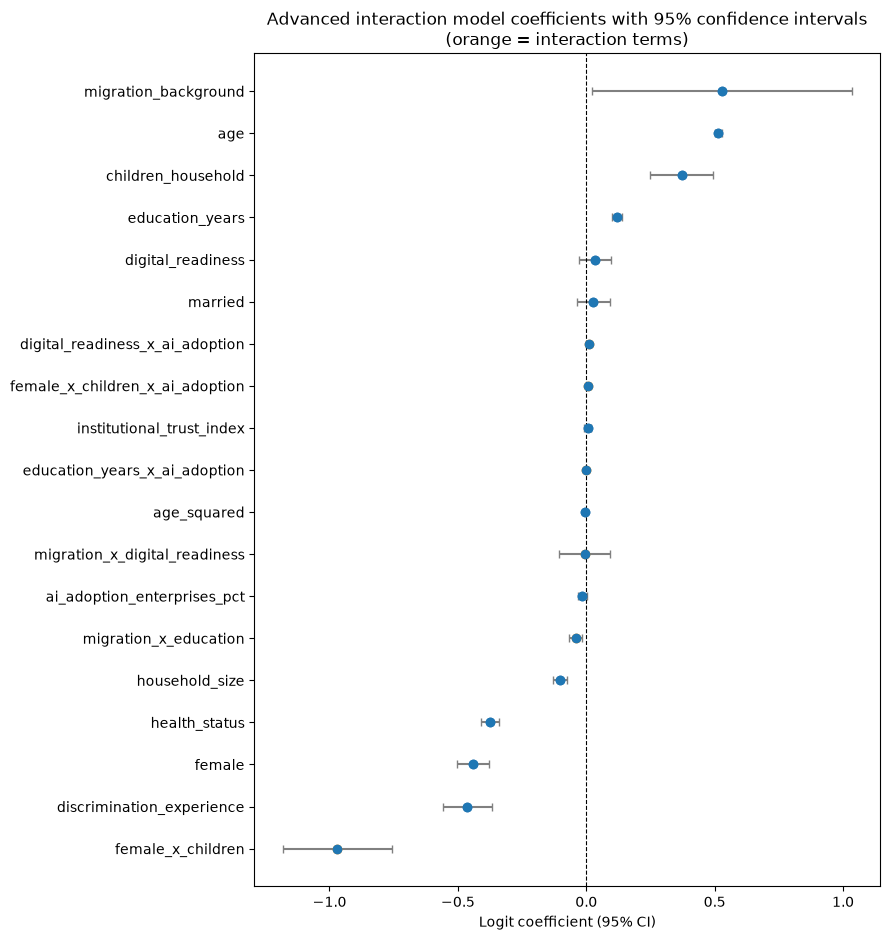

Saved coefficient plot to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\figures\advanced_econometric_coefficients.png


In [33]:
plot_table = interaction_table.loc[interaction_table['variable'] != 'Intercept'].copy().sort_values('coef')
errors = [plot_table['coef'] - plot_table['ci_low'], plot_table['ci_high'] - plot_table['coef']]

fig, ax = plt.subplots(figsize=(9, max(4, 0.5 * len(plot_table))))
colors = ['darkorange' if v in available_interaction_vars_with_triple else 'steelblue' for v in plot_table['variable']]
ax.errorbar(plot_table['coef'], plot_table['variable'], xerr=errors, fmt='o', ecolor='gray', capsize=3)
for y, (color, x) in enumerate(zip(colors, plot_table['coef'])):
    ax.plot(x, y, 'o', color=color)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel(f'{interaction_model_type} coefficient (95% CI)')
ax.set_title('Advanced interaction model coefficients with 95% confidence intervals\n(orange = interaction terms)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'advanced_econometric_coefficients.png', dpi=150)
plt.show()

print('Saved coefficient plot to:', FIGURES_DIR / 'advanced_econometric_coefficients.png')

In [34]:
interpretation_lines = [
    '# Advanced Econometric Interpretation',
    '',
    'Generated by notebooks/05_advanced_econometric_models.ipynb. All statements use',
    'association language only ("is associated with", "predicts", "correlates with") --',
    'no causal claims are made. This notebook extends notebook 04 (baseline models,',
    'already validated) with VIF checks, interaction models, marginal effects at',
    'representative AI adoption levels, survey weighting, country-clustered standard',
    'errors, and targeted robustness checks.',
    '',
    '## Modelling Sample',
    '',
    f'- Rows before listwise deletion: {n_before}',
    f'- Rows in main modelling sample: {n_after} ({n_dropped} dropped due to missing values)',
    f'- Base variables used (identical to notebook 04): {available_base_vars}',
    f'- Interaction terms used: {available_interaction_vars_with_triple}',
    f'- Excluded (missing or unavailable): '
    f'{[row["variable"] for row in excluded_base + excluded_interactions + excluded_triple] if (excluded_base or excluded_interactions or excluded_triple) else "none"}',
    '',
    '## VIF (Multicollinearity) Check',
    '',
    f'- High VIF (>= {VIF_HIGH_THRESHOLD}) variables: {sorted(VIF_HIGH_SET) if VIF_HIGH_SET else "none"}',
    '- No variable was dropped solely due to its VIF value (see section 3 in the notebook for the full',
    '  explanation); interaction terms are expected to show elevated VIF against their own components.',
    '',
    '## Interaction Model',
    '',
    f'Estimated as: {interaction_model_type}.' + (f' {interaction_note}' if interaction_note else ''),
    '',
    '## Model Fit Diagnostics and Likelihood-Ratio Test',
    '',
    'AIC/BIC per model are included in the Model Comparison table below. ' 
    + lr_interaction_vs_base_summary,
    '',
    lr_interaction_vs_base_table.to_markdown(index=False) if not lr_interaction_vs_base_table.empty else '',
    '',
    '## Weighted vs. Unweighted Comparison',
    '',
    weighted_vs_unweighted_summary,
    '',
    '## Country-Clustered Standard Errors',
    '',
    country_clustered_summary,
    '',
    '## Country Fixed Effects with Interactions',
    '',
    country_fe_summary,
    '',
    '## Multilevel (Hierarchical) Logistic Regression with Random Intercepts by Country',
    '',
    multilevel_summary,
    '',
    multilevel_variance_table.to_markdown(index=False) if not multilevel_variance_table.empty else '',
    '',
    '## Model Comparison (Main Model + Robustness Checks)',
    '',
    model_comparison_table.to_markdown(index=False),
    '',
    '## Robustness Stability of Significant Variables',
    '',
    stability_table.to_markdown(index=False) if not stability_table.empty else 'No variables were significant in the main interaction model at p < 0.05.',
    '',
    '## Hypothesis-by-Hypothesis Interpretation',
    '',
]
for hyp, (text, _) in hypothesis_results.items():
    interpretation_lines.append(f'### {hyp}: {hypothesis_labels[hyp]}')
    interpretation_lines.append('')
    interpretation_lines.append(text)
    if hyp in interpretation_notes:
        interpretation_lines.append('')
        interpretation_lines.append(interpretation_notes[hyp])
    interpretation_lines.append('')

interpretation_path = REPORTS_DIR / 'advanced_econometric_interpretation.md'
with open(interpretation_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(interpretation_lines))

print('Saved advanced interpretation report to:', interpretation_path)
print('Next step: notebooks/06_machine_learning_models.ipynb')

Saved advanced interpretation report to: C:\Users\khamidov.m\OneDrive - Procter and Gamble\Desktop\Project\Project\employment_ai_europe_thesis\outputs\reports\advanced_econometric_interpretation.md
Next step: notebooks/06_machine_learning_models.ipynb
